# Introduction to Neural Networks

**Authors**: Clinton Mwangi, Victor Ruto.


**Introduction**:
In this practical, we will build a solid understanding of neural networks by starting from first principles. We will first implement the core components of a neural network from scratch using NumPy to help us gain a deeper understanding of how neural networks learn through forward propagation, loss computation, backpropagation, and optimization. We will also introduce the basics of building neural networks with PyTorch.

**Prerequisites**:
- Basic Python programming
- Basic familiarity with the PyTorch framework
- NumPy, especially vector and matrix operations
- Basic linear algebra (vectors, matrices, and matrix multiplication)
- Basic calculus (particularly derivatives and the chain rule)

**Topics**:
1. The Perceptron
2. Activation Functions
   - Sigmoid
   - Hyperbolic Tangent (Tanh)
   - Rectified Linear Unit (ReLU)
3. Multi-Layer Perceptrons (MLPs)
4. Forward Propagation
5. Loss Functions
6. Gradient Descent and Optimization
7. Backpropagation
8. Automatic Differentiation (Autograd)
9. Building Neural Networks with PyTorch
10. Training and Evaluating Neural Networks


## The Intuition: What are Neural Networks?

Machine Learning (ML) is a branch of Artificial Intelligence focused on building systems that learn from **data** to make predictions or draw inferences, rather than relying on explicit, hard-coded rules.

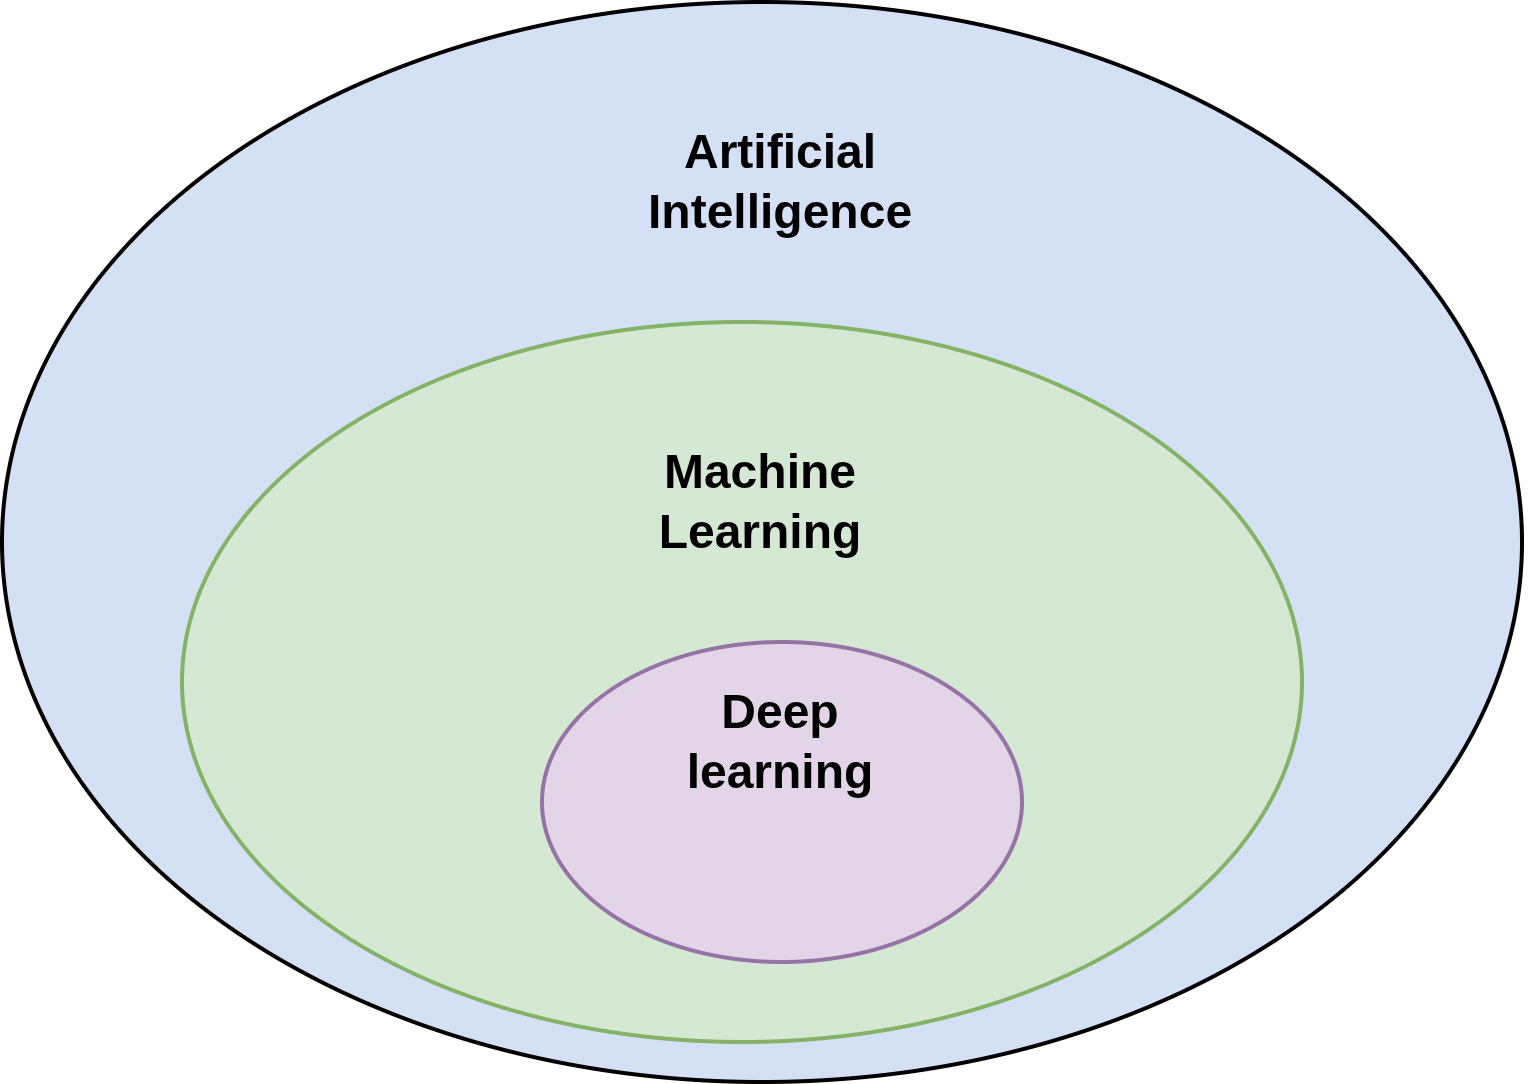

Source: Created by Authors


As illustrated in the Venn diagram, Deep Learning is a specialized subset of Machine Learning. It relies on **Neural Networks**.

*What are neural networks?*

Neural networks are a powerful class of machine learning models inspired by the structure and function of the human brain. The figure below illustrates the structure of biological neurons. We have two neurons that are interconnected, and each receives, processes, and transmits signals to others. The brain has a total of approximately 86 billion of these neurons that fire and transmit information to each other.

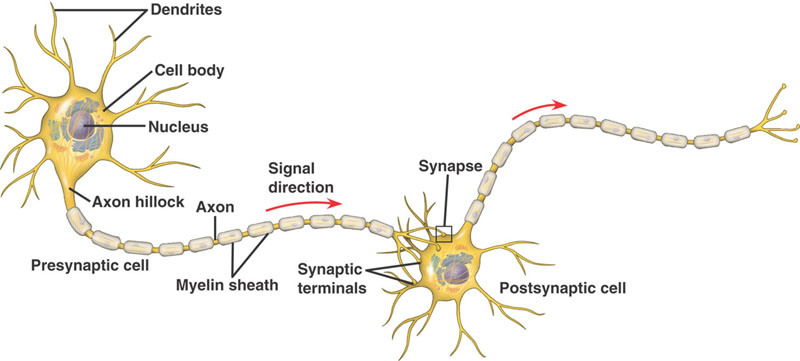

Source: [The Kurzweil Library, Neuron Structure](https://www.thekurzweillibrary.com/images/neuron_structure.jpg).


A neural network consist of interconnected computational units called **neurons** (or **nodes**) that communicate with one another by passing information through weighted connections. Just as biological neurons receive, process, and transmit signals, artificial neurons perform mathematical operations to transform input data into meaningful outputs.

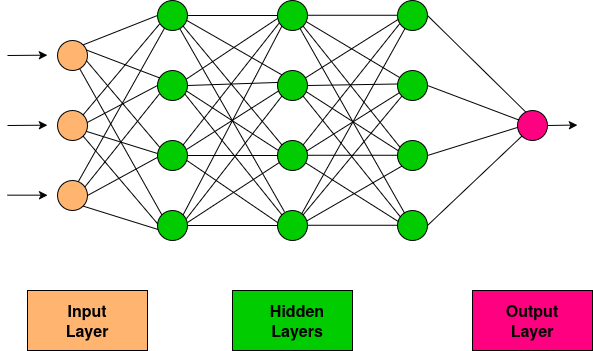

Source: Created by Authors


Unlike traditional algorithms that rely on explicit, hand-coded rules, neural networks automatically learn to approximate complex, non-linear functions directly from raw data. For example, identifying whether a medical image shows a specific disease is a highly non-linear problem—it is impossible to write simple "if-then" rules to account for every possible variation in lighting, shape, and texture across thousands of different X-rays.

In this lab, we will translate high-level intuition into working code, building the foundational components of neural networks entirely from scratch.


## Perceptron

### *What is a Perceptron?*

At its core, a perceptron is the simplest building block of an artificial neural network—a single artificial neuron. <br>
It functions as a basic decision-making algorithm. It takes a set of numerical inputs, multiplies each by a specific weight (which represents the importance of that input), sums them all together, and adds a bias. Finally, it passes this combined signal through an activation function to output a simple binary decision (for example, a 1 or a 0). If the total signal crosses a certain threshold, the neuron "fires." See diagram below:

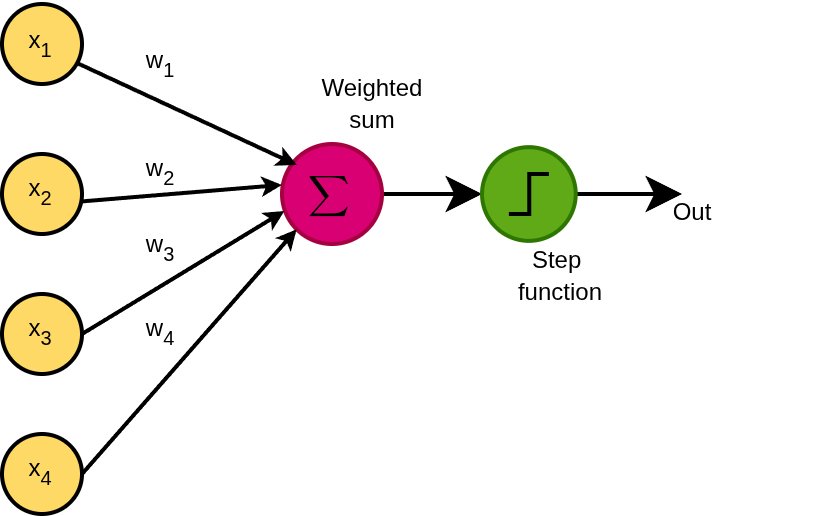

Source: Created by Authors


### *The origin of Perceptron:*
Long before we had modern deep learning frameworks, the foundations were being laid in hardware.

In 1957, Frank Rosenblatt from the Cornell Aeronautical Laboratory made the first attempts at implementing something similar to an artificial neural network. His creation, the original Perceptron, was actually a custom-built hardware machine designed to recognize primitive geometric shapes such as triangles, squares, and circles.

Read the Original Research: > Rosenblatt, F. (1958). The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain. Psychological Review, 65(6), 386–408. [Read the paper here.](https://www.ling.upenn.edu/courses/cogs501/Rosenblatt1958.pdf)

### *Perceptron Model*

A perceptron is a **binary classification** model, i.e., it can distinguish between two classes of input data. Suppose we have $N$ features in our model, in which case the input vector would be a vector $\mathbf{x}$ of size $N$. . We will assume that for each input vector $\mathbf{x}$, the output of our perceptron would be either $+1$ or $-1$, depending on the class.

The output is computed using a combination of a weight vector ($\mathbf{w}$) and a **bias** ($b$) term. The formula is:

$$y(\mathbf{x}) = f(\mathbf{w}^T\mathbf{x} + b)$$

where $f$ is a step activation function applied to the resulting scalar $z$ (where $z = \mathbf{w}^T\mathbf{x} + b$):

$$f(z) = \begin{cases} +1 & z \ge 0 \\ -1 & z < 0 \end{cases}$$

In practice, the perceptron uses the weight vector $\mathbf{w}$ to determine the orientation of a straight decision boundary, while the bias $b$ shifts this boundary so it is not forced to pass through the origin. By evaluating which side of this boundary a new data point $\mathbf{x}$ falls on, the step function instantly assigns it to the correct class.

Let's work with a toy dataset to build this intuition. we will generate a simple, synthetic 2D dataset. We will create $n$ samples with 2 features ($x_1$ and $x_2$) that are **linearly separable**. This means we can draw a single straight line to perfectly divide the two classes.

We will use scikit-learn's `make_classification` to generate the data, convert the labels from `0/1` to `-1/+1` (to match our perceptron's step function output), and split the data into training and testing sets.

In [1]:
# Lets import all the modules we need.

import pylab
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib import gridspec
from sklearn.datasets import make_classification
import numpy as np
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pickle
import os
import gzip

# pick the seed for reproducability - change it to explore the effects of random variations
np.random.seed(1)
import random

In [2]:
n = 100
X, y = make_classification(n_samples = n, n_features=2,
                           n_redundant=0, n_informative=2, flip_y=0)
y = y*2-1 # convert initial 0/1 values into -1/1
X = X.astype(np.float32); y = y.astype(np.int32) # features - float, label - int

# Split the dataset into training and test
train_x, test_x = np.split(X, [ n*8//10])
train_labels, test_labels = np.split(y, [n*8//10])

print("Features:\n",train_x[0:4])
print("Labels:\n",train_labels[0:4])

Features:
 [[ 1.3002272  -0.7856539 ]
 [ 1.4418442  -0.56008554]
 [-0.8479245  -1.3662132 ]
 [-0.72215015 -1.4112941 ]]
Labels:
 [ 1  1 -1 -1]


Lets visualize the dataset.

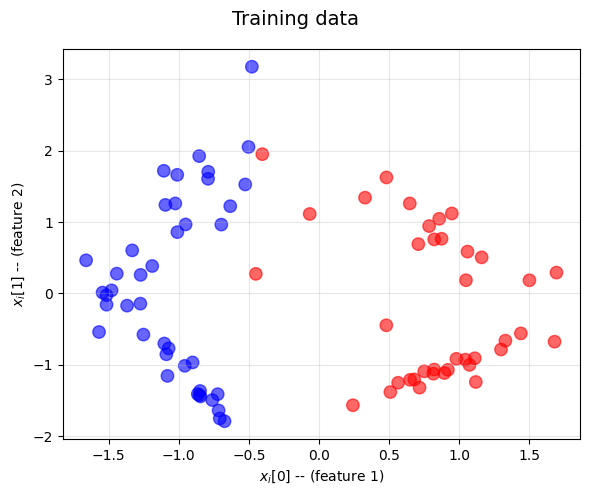

In [3]:
def plot_dataset(suptitle, features, labels):
    fig, ax = pylab.subplots(1, 1, figsize=(6, 5))
    fig.suptitle(suptitle, fontsize=14)
    ax.set_xlabel('$x_i[0]$ -- (feature 1)')
    ax.set_ylabel('$x_i[1]$ -- (feature 2)')
    colors = ['r' if l>0 else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=80, alpha=0.6)
    ax.grid(True, alpha=0.3)
    pylab.tight_layout()
    fig.show()

plot_dataset('Training data', train_x, train_labels)

The plot above visualizes our training data. As you can see, we have two distinct classes (represented by red and blue dots) that are clearly separated. Because there is a distinct gap between the two groups, a single-layer perceptron will be able to learn a straight decision boundary to perfectly classify this dataset.

Now that we have our data, let's look at how the perceptron actually finds this boundary using its training algorithm.

### *Training the Perceptron*

To train the perceptron, we need to find the optimal weights $\mathbf{w}$ and bias $b$ that minimize classification errors. We define this error using the **perceptron criterion**:

$$E(\mathbf{w}, b) = -\sum_{n \in \mathcal{M}} (\mathbf{w}^{T}\mathbf{x}_{n} + b)t_{n}$$

Where:
* $t_{n} \in \{-1, +1\}$ represents the true labels for the training samples.
* $\mathcal{M}$ is the set of *currently misclassified* examples.

To minimize this error, we use **Gradient Descent** (which we will discuss in depth later). This an optimization algorithm that iteratively adjusts parameters by taking small steps down the slope (the gradient) of the error surface to find the lowest possible error.

Starting with random initial weights $\mathbf{w}^{(0)}$ and bias $b^{(0)}$, we update them at each iteration $\tau$ by adding the negative gradient:

$$\mathbf{w}^{(\tau + 1)} = \mathbf{w}^{(\tau)} + \eta \sum_{n \in \mathcal{M}} \mathbf{x}_{n} t_{n}$$

$$b^{(\tau + 1)} = b^{(\tau)} + \eta \sum_{n \in \mathcal{M}} t_{n}$$

Here, $\eta$ (eta) is the **learning rate**—a small tuning parameter that controls the step size of each update. If the learning rate is too large, the model might jump over the optimal solution; if it is too small, the training process will take a very long time to converge.

Let's define this algorithm in Python:

In [4]:
def train(positive_examples, negative_examples, num_iterations = 100, learning_rate = 0.01):
    num_dims = positive_examples.shape[1]

    # Initialize weights.
    # We initialize with 0 for simplicity, but random initialization is also a good idea
    weights = np.zeros((num_dims,1))

    pos_count = positive_examples.shape[0]
    neg_count = negative_examples.shape[0]

    report_frequency = 10

    for i in range(num_iterations):
        # Pick one positive and one negative example
        pos = random.choice(positive_examples)
        neg = random.choice(negative_examples)

        z = np.dot(pos, weights) #What this mean and is it equivalent to what we have in the formula?
        if z < 0: # positive example was classified as negative
            weights = weights + learning_rate * pos.reshape(weights.shape)

        z  = np.dot(neg, weights)
        if z >= 0: # negative example was classified as positive
            weights = weights - learning_rate * neg.reshape(weights.shape)

        # Periodically, print out the current accuracy on all examples
        if i % report_frequency == 0:
            pos_out = np.dot(positive_examples, weights)
            neg_out = np.dot(negative_examples, weights)
            pos_correct = (pos_out >= 0).sum() / float(pos_count)
            neg_correct = (neg_out < 0).sum() / float(neg_count)
            print("Iteration={}, pos correct={}, neg correct={}".format(i,pos_correct,neg_correct))

    return weights

In [5]:
pos_examples = np.array([ [t[0], t[1], 1] for i,t in enumerate(train_x)
                          if train_labels[i]>0])
neg_examples = np.array([ [t[0], t[1], 1] for i,t in enumerate(train_x)
                          if train_labels[i]<0])
print(pos_examples[0:3])

[[ 1.30022717 -0.78565389  1.        ]
 [ 1.44184422 -0.56008554  1.        ]
 [ 0.78694272  0.94294876  1.        ]]


**Note on Learning Rate**: The `learning_rate` parameter (default `0.01`) controls how much we adjust the weights during each training step. This implements the gradient descent update formula:

$$\mathbf{w}^{\tau + 1}=\mathbf{w}^{\tau} + \eta \mathbf{x}_{n} t_{n}$$

- A larger learning rate (e.g., `1.0`) makes the perceptron learn faster but may overshoot the optimal solution
- A smaller learning rate (e.g., `0.001`) learns more slowly but may converge more precisely
- You can experiment by calling: `train(pos_examples, neg_examples, learning_rate=0.1)`


In [6]:
# The weights
wts = train(pos_examples,neg_examples)
print(wts.transpose)

Iteration=0, pos correct=0.42105263157894735, neg correct=0.7142857142857143
Iteration=10, pos correct=0.8947368421052632, neg correct=0.8571428571428571
Iteration=20, pos correct=0.9473684210526315, neg correct=1.0
Iteration=30, pos correct=0.9210526315789473, neg correct=1.0
Iteration=40, pos correct=0.9210526315789473, neg correct=1.0
Iteration=50, pos correct=0.9210526315789473, neg correct=1.0
Iteration=60, pos correct=0.9736842105263158, neg correct=0.9761904761904762
Iteration=70, pos correct=0.9736842105263158, neg correct=0.9761904761904762
Iteration=80, pos correct=1.0, neg correct=0.8095238095238095
Iteration=90, pos correct=0.9210526315789473, neg correct=1.0
<built-in method transpose of numpy.ndarray object at 0x7ceb145338d0>


To better understand what our model has actually learned, let's visualize the linear decision boundary it generated to separate the two classes.

In [7]:
def plot_boundary(positive_examples, negative_examples, weights):
    if np.isclose(weights[1], 0): #Avoid division by zero
        if np.isclose(weights[0], 0):
            x = y = np.array([-6, 6], dtype = 'float32')
        else:
            y = np.array([-6, 6], dtype='float32')
            x = -(weights[1] * y + weights[2])/weights[0]
    else:
        x = np.array([-6, 6], dtype='float32')
        y = -(weights[0] * x + weights[2])/weights[1]

    pylab.xlim(-6, 6)
    pylab.ylim(-6, 6)
    pylab.plot(positive_examples[:,0], positive_examples[:,1], 'bo')
    pylab.plot(negative_examples[:,0], negative_examples[:,1], 'ro')
    pylab.plot(x, y, 'g', linewidth=2.0)
    pylab.show()

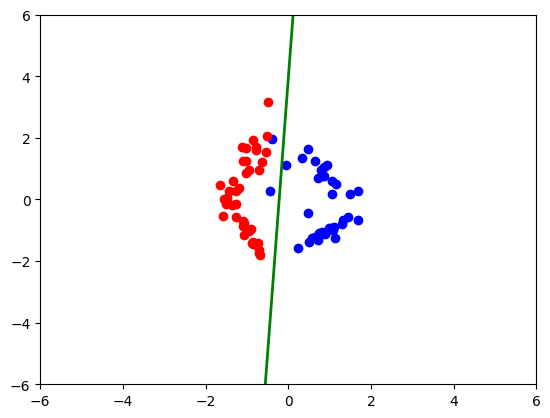

In [8]:
plot_boundary(pos_examples,neg_examples,wts)

Lets compare different learning rates.

Iteration=0, pos correct=0.5526315789473685, neg correct=0.6666666666666666
Iteration=10, pos correct=0.9473684210526315, neg correct=0.9761904761904762
Iteration=20, pos correct=0.868421052631579, neg correct=1.0
Iteration=30, pos correct=0.9736842105263158, neg correct=0.9047619047619048
Iteration=40, pos correct=0.9736842105263158, neg correct=0.9761904761904762
Iteration=50, pos correct=1.0, neg correct=0.9523809523809523
Iteration=60, pos correct=1.0, neg correct=0.9523809523809523
Iteration=70, pos correct=1.0, neg correct=0.9523809523809523
Iteration=80, pos correct=1.0, neg correct=0.9523809523809523
Iteration=90, pos correct=1.0, neg correct=0.9523809523809523
Iteration=0, pos correct=0.631578947368421, neg correct=1.0
Iteration=10, pos correct=0.9473684210526315, neg correct=0.9523809523809523
Iteration=20, pos correct=0.8947368421052632, neg correct=1.0
Iteration=30, pos correct=0.8947368421052632, neg correct=1.0
Iteration=40, pos correct=0.8947368421052632, neg correct=1.0

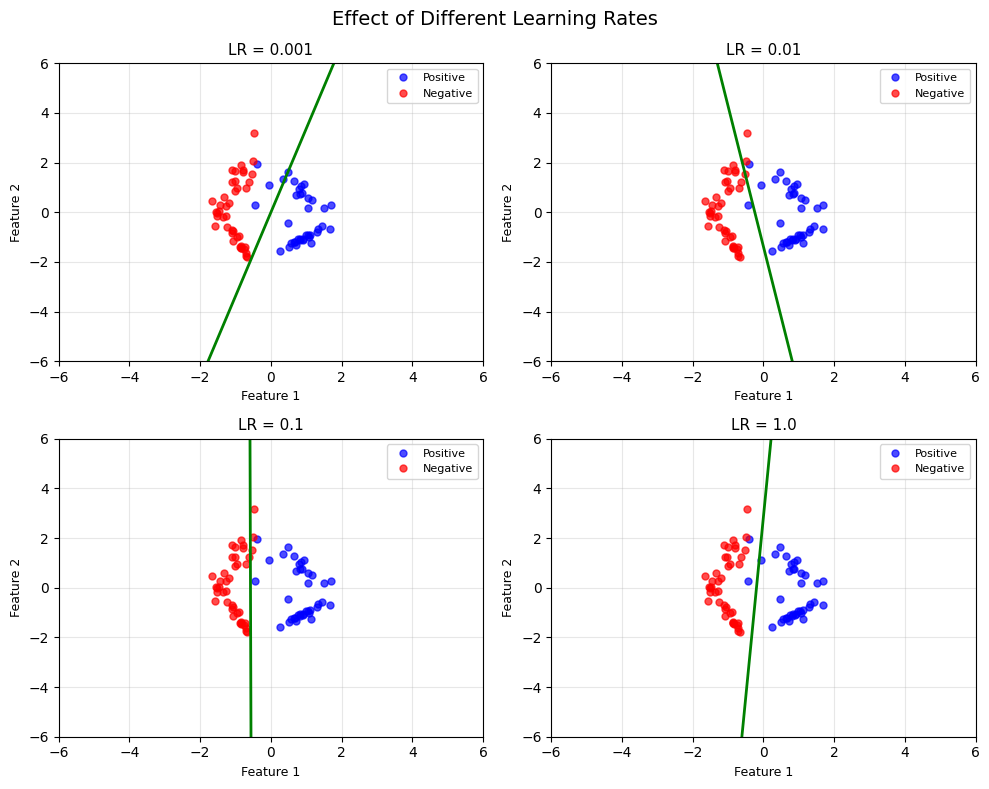

In [9]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
fig, axes = pylab.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Effect of Different Learning Rates', fontsize=14)

for idx, lr in enumerate(learning_rates):
    ax = axes[idx // 2, idx % 2]

    # Train with this learning rate
    weights_lr = train(pos_examples, neg_examples, num_iterations=100, learning_rate=lr)

    # Plot decision boundary
    if np.isclose(weights_lr[1], 0):
        if np.isclose(weights_lr[0], 0):
            x = y = np.array([-6, 6], dtype='float32')
        else:
            y = np.array([-6, 6], dtype='float32')
            x = -(weights_lr[1] * y + weights_lr[2])/weights_lr[0]
    else:
        x = np.array([-6, 6], dtype='float32')
        y = -(weights_lr[0] * x + weights_lr[2])/weights_lr[1]

    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.plot(pos_examples[:, 0], pos_examples[:, 1], 'bo', label='Positive', alpha=0.7, markersize=5)
    ax.plot(neg_examples[:, 0], neg_examples[:, 1], 'ro', label='Negative', alpha=0.7, markersize=5)
    ax.plot(x, y, 'g-', linewidth=2)
    ax.set_title(f'LR = {lr}', fontsize=11)
    ax.set_xlabel('Feature 1', fontsize=9)
    ax.set_ylabel('Feature 2', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

pylab.tight_layout()
pylab.show()

In [10]:
def train_and_plot_with_lr(learning_rate=0.01):
    """Train perceptron with specified learning rate and plot results"""
    weights_lr = train(pos_examples, neg_examples, num_iterations=100, learning_rate=learning_rate)

    fig, (ax1, ax2) = pylab.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Decision boundary
    if np.isclose(weights_lr[1], 0):
        if np.isclose(weights_lr[0], 0):
            x = y = np.array([-6, 6], dtype='float32')
        else:
            y = np.array([-6, 6], dtype='float32')
            x = -(weights_lr[1] * y + weights_lr[2])/weights_lr[0]
    else:
        x = np.array([-6, 6], dtype='float32')
        y = -(weights_lr[0] * x + weights_lr[2])/weights_lr[1]

    ax1.set_xlim(-6, 6)
    ax1.set_ylim(-6, 6)
    ax1.plot(pos_examples[:, 0], pos_examples[:, 1], 'bo', label='Positive', markersize=10, alpha=0.6)
    ax1.plot(neg_examples[:, 0], neg_examples[:, 1], 'ro', label='Negative', markersize=10, alpha=0.6)
    ax1.plot(x, y, 'g-', linewidth=3, label='Decision Boundary')

    ax1.set_title(f'Decision Boundary (lr={learning_rate})', fontsize=14)
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Weight values
    ax2.bar(['w0', 'w1', 'bias'], weights_lr.flatten(), color=['blue', 'green', 'red'], alpha=0.7)
    ax2.set_title('Final Weight Values', fontsize=14)
    ax2.set_ylabel('Weight Value')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    pylab.tight_layout()
    pylab.show()

    print(f"Final weights: {weights_lr.flatten()}")

# Create interactive widget
interact(train_and_plot_with_lr,
         learning_rate=widgets.FloatSlider(value=0.01, min=0.001, max=1.0, step=0.001,
                                           description='Learning Rate:', continuous_update=False))

interactive(children=(FloatSlider(value=0.01, continuous_update=False, description='Learning Rate:', max=1.0, …

<function __main__.train_and_plot_with_lr(learning_rate=0.01)>

### *Evaluating on the test dataset*

In [11]:
def accuracy(weights, test_x, test_labels):
    res = np.dot(np.c_[test_x,np.ones(len(test_x))],weights)
    return (res.reshape(test_labels.shape)*test_labels>=0).sum()/float(len(test_labels))

accuracy(wts, test_x, test_labels)

np.float64(1.0)

To verify our model's performance, we evaluate it on the unseen test dataset. Since our toy dataset is perfectly linearly separable, the trained perceptron is expected to achieve very high accuracy.

### *Observing the training process*

We have seen before how the accuracy increases during training. It would be nice to see how the separation line behaves during training. The code below will visualize everything on one graph, and you should be able to move the slider to "time-travel" through the training process.

In [12]:
def train_graph(positive_examples, negative_examples, num_iterations = 100, learning_rate = 0.01):
    num_dims = positive_examples.shape[1]
    weights = np.zeros((num_dims,1)) # initialize weights

    pos_count = positive_examples.shape[0]
    neg_count = negative_examples.shape[0]
    report_frequency = 15;
    snapshots = []

    for i in range(num_iterations):
        pos = random.choice(positive_examples)
        neg = random.choice(negative_examples)

        z = np.dot(pos, weights)
        if z < 0:
            weights = weights + learning_rate * pos.reshape(weights.shape)

        z  = np.dot(neg, weights)
        if z >= 0:
            weights = weights - learning_rate * neg.reshape(weights.shape)

        if i % report_frequency == 0:
            pos_out = np.dot(positive_examples, weights)
            neg_out = np.dot(negative_examples, weights)
            pos_correct = (pos_out >= 0).sum() / float(pos_count)
            neg_correct = (neg_out < 0).sum() / float(neg_count)
            snapshots.append([np.copy(weights).flatten(), (pos_correct+neg_correct)/2.0])

    return np.array(snapshots, dtype=object)

snapshots = train_graph(pos_examples,neg_examples)

def plotit(pos_examples,neg_examples,snapshots,step):
    fig = pylab.figure(figsize=(10,4))
    fig.add_subplot(1, 2, 1)
    plot_boundary(pos_examples, neg_examples, snapshots[step][0])
    fig.add_subplot(1, 2, 2)
    pylab.plot(np.arange(len(snapshots[:,1])), snapshots[:,1])
    pylab.ylabel('Accuracy')
    pylab.xlabel('Iteration')
    pylab.plot(step, snapshots[step,1], "bo")
    pylab.show()

def pl1(step):
     plotit(pos_examples,neg_examples,snapshots,step)

In [13]:
interact(pl1, step=widgets.IntSlider(value=0, min=0, max=len(snapshots)-1))

interactive(children=(IntSlider(value=0, description='step', max=6), Output()), _dom_classes=('widget-interact…

<function __main__.pl1(step)>


### *Limitations of the Perceptron*

As you have seen above, perceptron is a **linear classifier**. It can distinguish between two classes well if they are **linearly separable**, i.e. can be separated by a straight line. Otherwise, perceptron training process will not converge.

A most obvious example of a problem that cannot be solved by a perceptron is so-called **XOR problem**. We want our perceptron to learn the XOR boolean function, which has the following truth table:

|   | 0 | 1 |
|---|---|---|
| 0 | 0 | 1 |
| 1 | 1 | 0 |

Let's try and do that! We will manually populate all positive and negative training samples, and then call our train function defined above:

In [14]:
pos_examples_xor = np.array([[1,0,1],[0,1,1]])
neg_examples_xor = np.array([[1,1,1],[0,0,1]])

snapshots_xor = train_graph(pos_examples_xor,neg_examples_xor,100)
def pl2(step): plotit(pos_examples_xor,neg_examples_xor,snapshots_xor,step)

In [15]:
interact(pl2, step=widgets.IntSlider(value=0, min=0, max=len(snapshots)-1))

interactive(children=(IntSlider(value=0, description='step', max=6), Output()), _dom_classes=('widget-interact…

<function __main__.pl2(step)>

As you can see from the graph above, the accuracy never goes above 75%, because it is impossible to draw a straight line in such a way as to get all possible examples right.

The XOR problem is a classical example of perceptron limitations, and it was pointed out by Marvin Minsky and Seymour Papert in 1969 in their book Perceptrons). This observation limited research in the area of neural networks for almost 10 years, even though - and we will see this in the next section of our course - multi-layered perceptrons are perfectly capable of solving such problems.

## Activation functions

### *Why Do We Need Activation Functions?*

So far, we have worked with a simple **step function** in our perceptron model. But this raises an important question: as we build larger networks, why do we need more advanced activation functions?

If a neural network only relied on weights and biases (which are strictly linear operations), stacking multiple layers wouldn't actually accomplish anything new. Mathematically, a dozen linear layers combined simply collapse back down into one single linear layer.
<br>The network would only ever be able to understand straight lines.

To prove why non-linearity is essential, let's look at the algebra. If we have two sequential linear layers without an activation function, the math looks like this:

* **Layer 1:** $y_1 = \mathbf{W}_1\mathbf{x} + \mathbf{b}_1$
* **Layer 2:** $y_2 = \mathbf{W}_2y_1 + \mathbf{b}_2$

If we substitute Layer 1 into Layer 2, we get:
$$y_2 = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2$$
$$y_2 = (\mathbf{W}_2\mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2)$$

This mathematically simplifies down to $y_2 = \mathbf{W}_{combined}\mathbf{x} + \mathbf{b}_{combined}$. No matter how many linear layers you stack, they completely collapse into a single linear operation.

In [16]:
# 1. Dummy input and weights for two layers
np.random.seed(42)
x = np.random.randn(3, 1)
W1 = np.random.randn(4, 3)
b1 = np.random.randn(4, 1)
W2 = np.random.randn(2, 4)
b2 = np.random.randn(2, 1)

# 2. Forward pass through TWO stacked linear layers
y1 = np.dot(W1, x) + b1
y2_stacked = np.dot(W2, y1) + b2

# 3. Collapse into a SINGLE linear layer
W_combined = np.dot(W2, W1)
b_combined = np.dot(W2, b1) + b2
y2_single = np.dot(W_combined, x) + b_combined

print(y2_stacked, y2_single)
# 4. Compare the results
print("Are the outputs identical?", np.allclose(y2_stacked, y2_single))

[[-0.85504933]
 [ 1.56683033]] [[-0.85504933]
 [ 1.56683033]]
Are the outputs identical? True


**Activation Functions** are the solution to this limitation. They are mathematical equations applied to the output of each neuron that decide whether the neuron's signal should be "activated" (passed forward) or ignored.

Crucially, they introduce **non-linearity** into the network. This non-linearity is exactly what allows the neural network to bend those straight lines, enabling it to learn and approximate complex, real-world patterns.


### *Modern activation functions:*

#### 1. Sigmoid
The Sigmoid function takes any input number (from negative infinity to positive infinity) and squashes it into a tight range between $0$ and $1$.

$$f(x)=\frac{1}{1+e^{-x}}$$

**Derivative:**
$$f'(x)=f(x)(1-f(x))$$

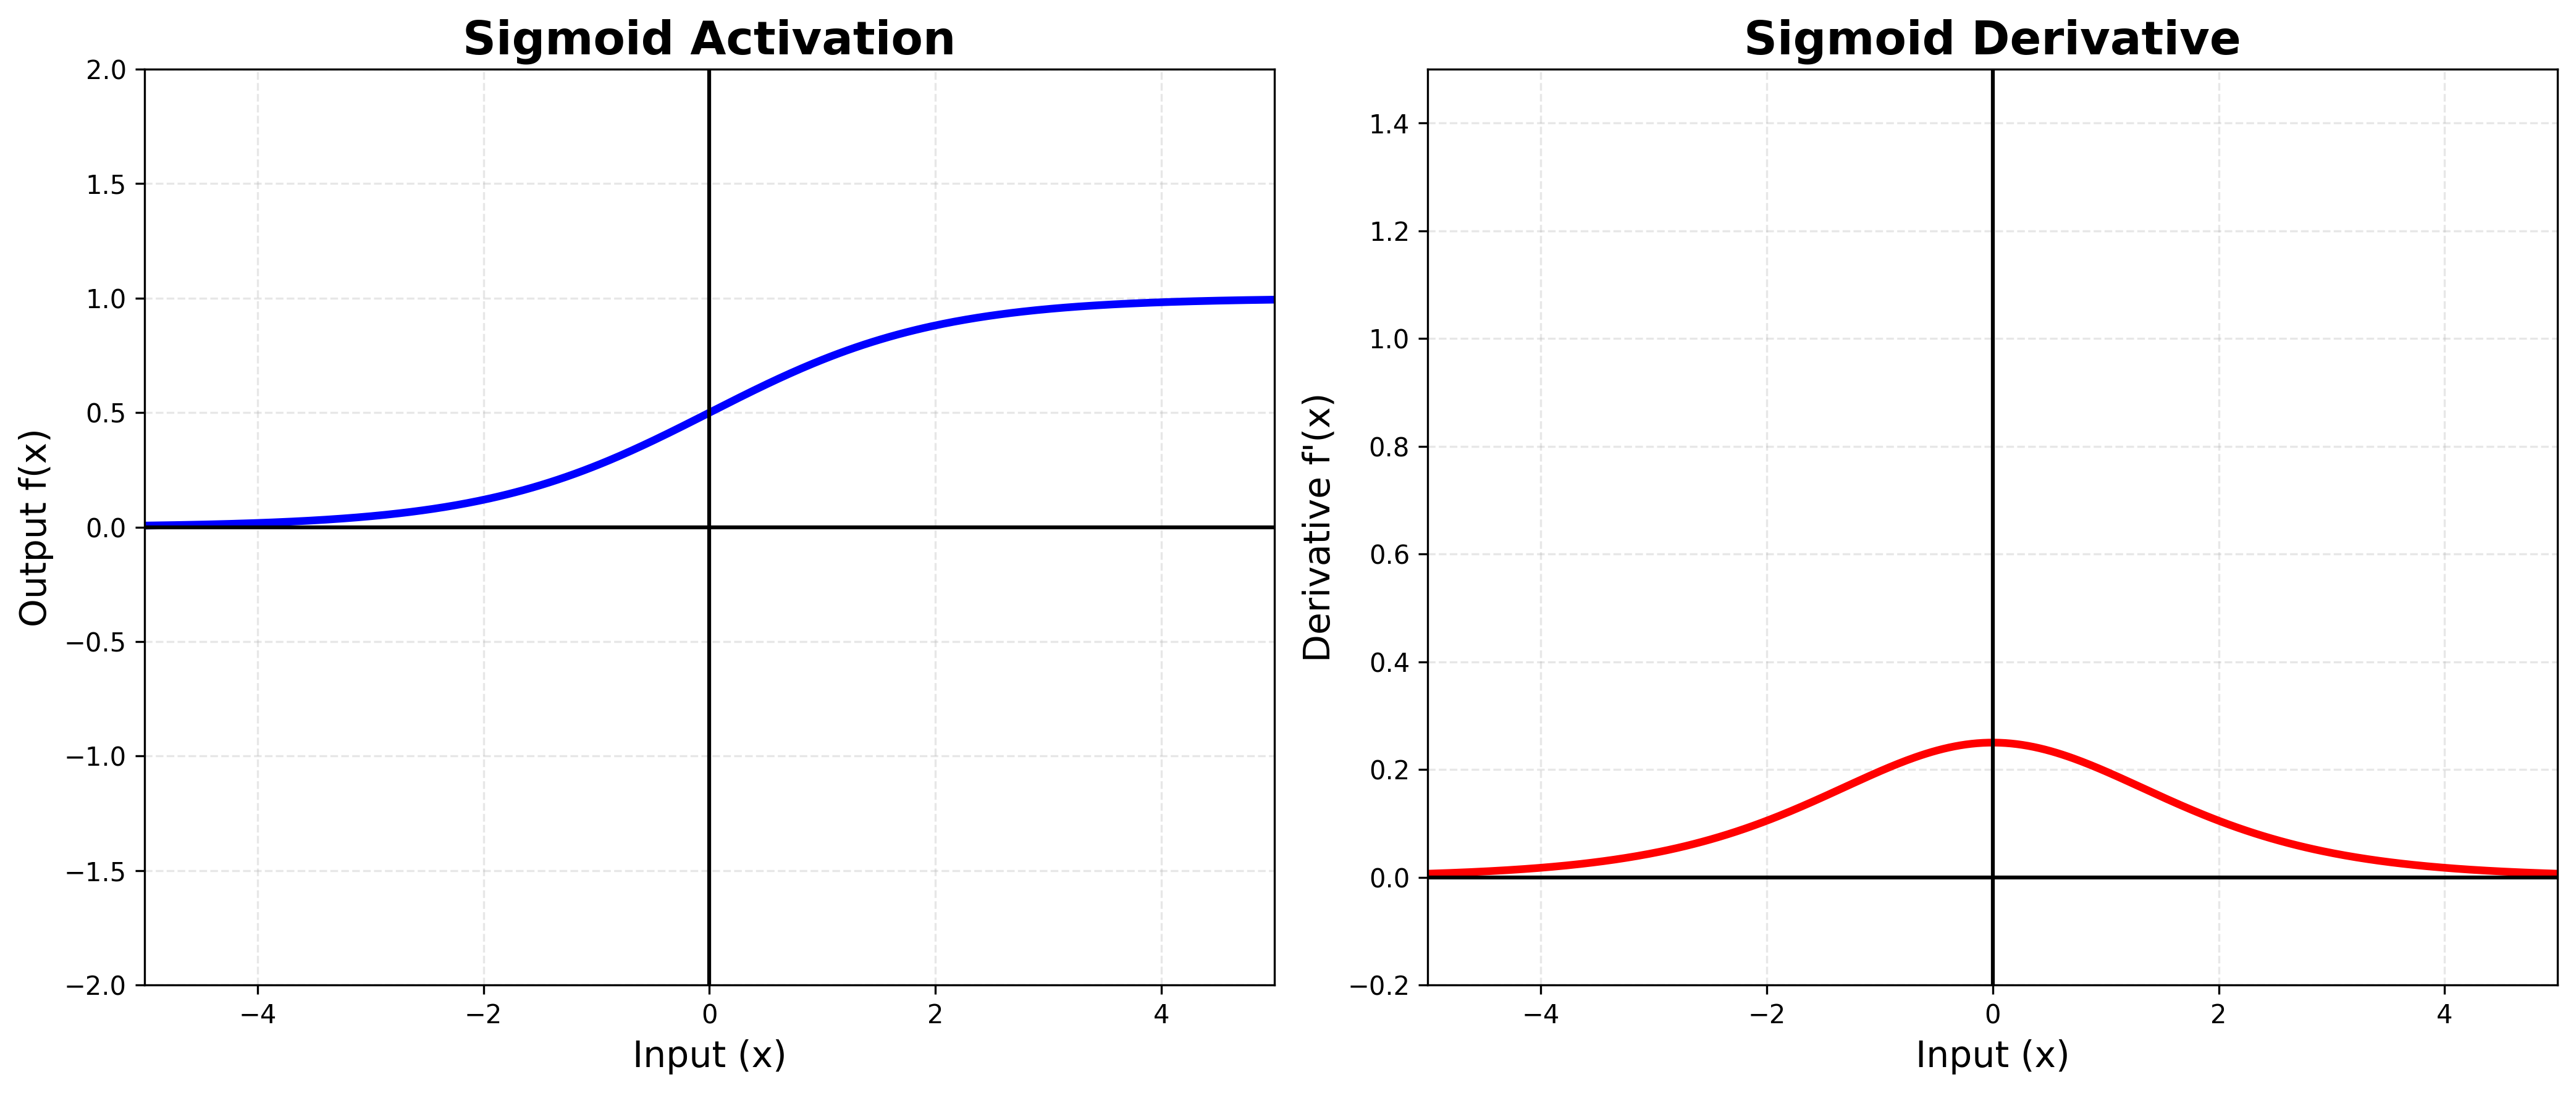

*   **Pros:** Because its output is between 0 and 1, it is perfect for models where we need to predict a probability (e.g., a binary classification of whether a scan shows a tumor or not).
*   **Cons:** It suffers from the "vanishing gradient" problem. For very high or very low inputs, the curve becomes incredibly flat. A flat curve means a slope of zero, and if the gradient is zero, the network stops learning.

---

#### 2. Tanh (Hyperbolic Tangent)
Tanh is very similar to Sigmoid, but instead of squashing numbers between 0 and 1, it squashes them between $-1$ and $1$.

$$f(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}$$

**Derivative:**
$$f'(x)=1-f(x)^2$$

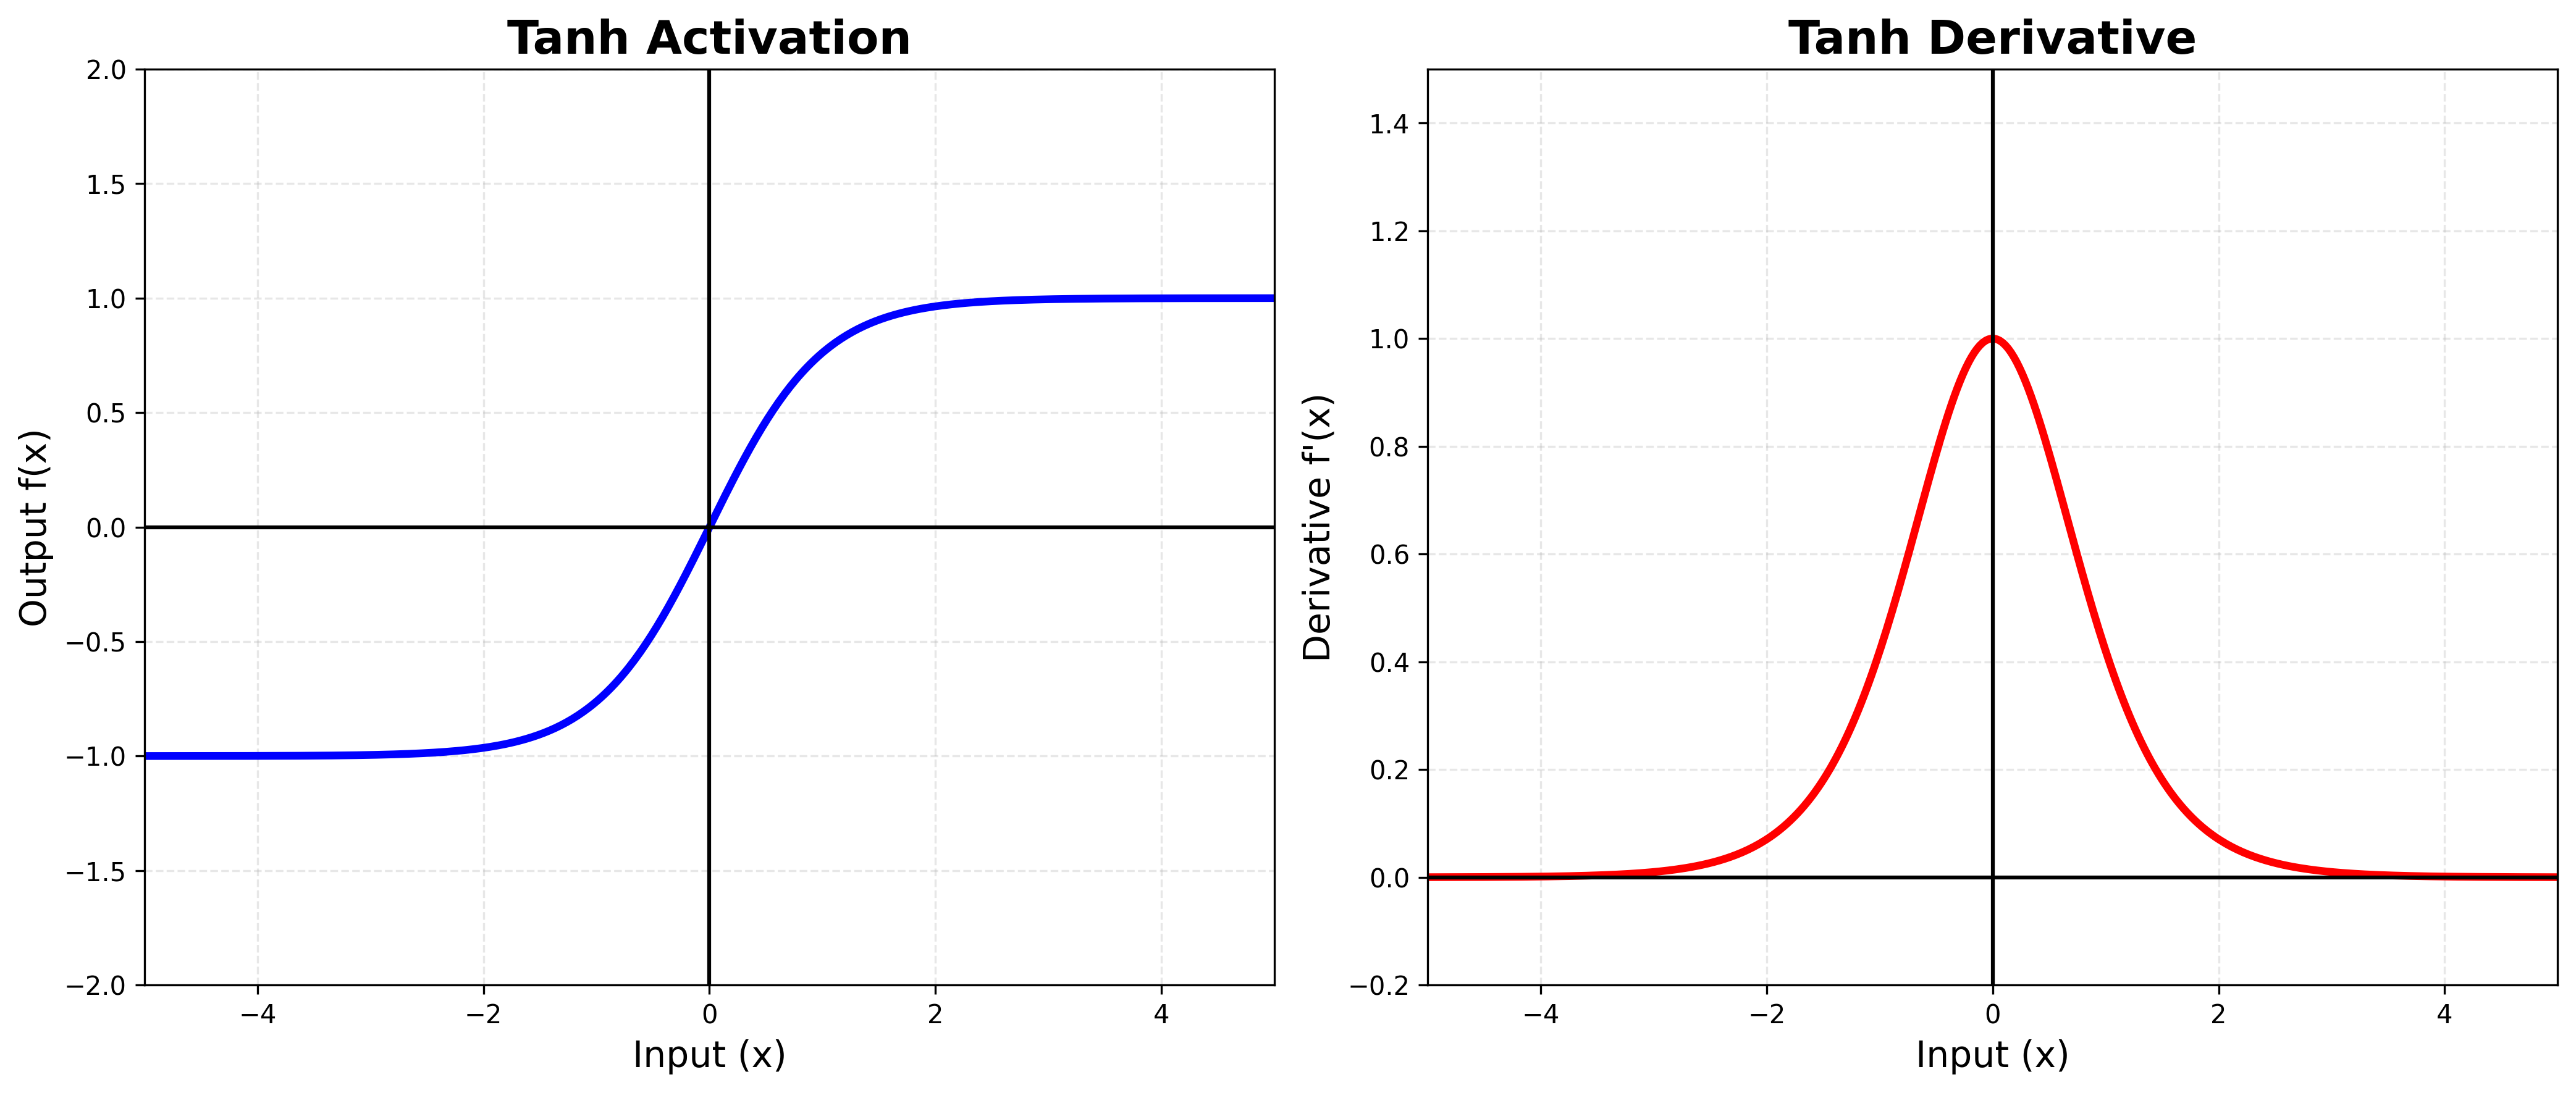

*   **Pros:** Unlike Sigmoid, Tanh is zero-centered. This means negative inputs will be mapped strongly negative, and zero inputs will be mapped near zero, which generally makes optimization easier and faster during training.
*   **Cons:** Like Sigmoid, it still suffers from vanishing gradients at the extreme ends of the curve.

---

#### 3. ReLU (Rectified Linear Unit)
ReLU is incredibly simple but revolutionized deep learning. If the input is negative, it outputs exactly zero. If the input is positive, it outputs the raw input unchanged.

$$f(x)=\max(0,x)$$

**Derivative:**
$$f'(x)=\begin{cases}1&x>0\\0&x\le0\end{cases}$$

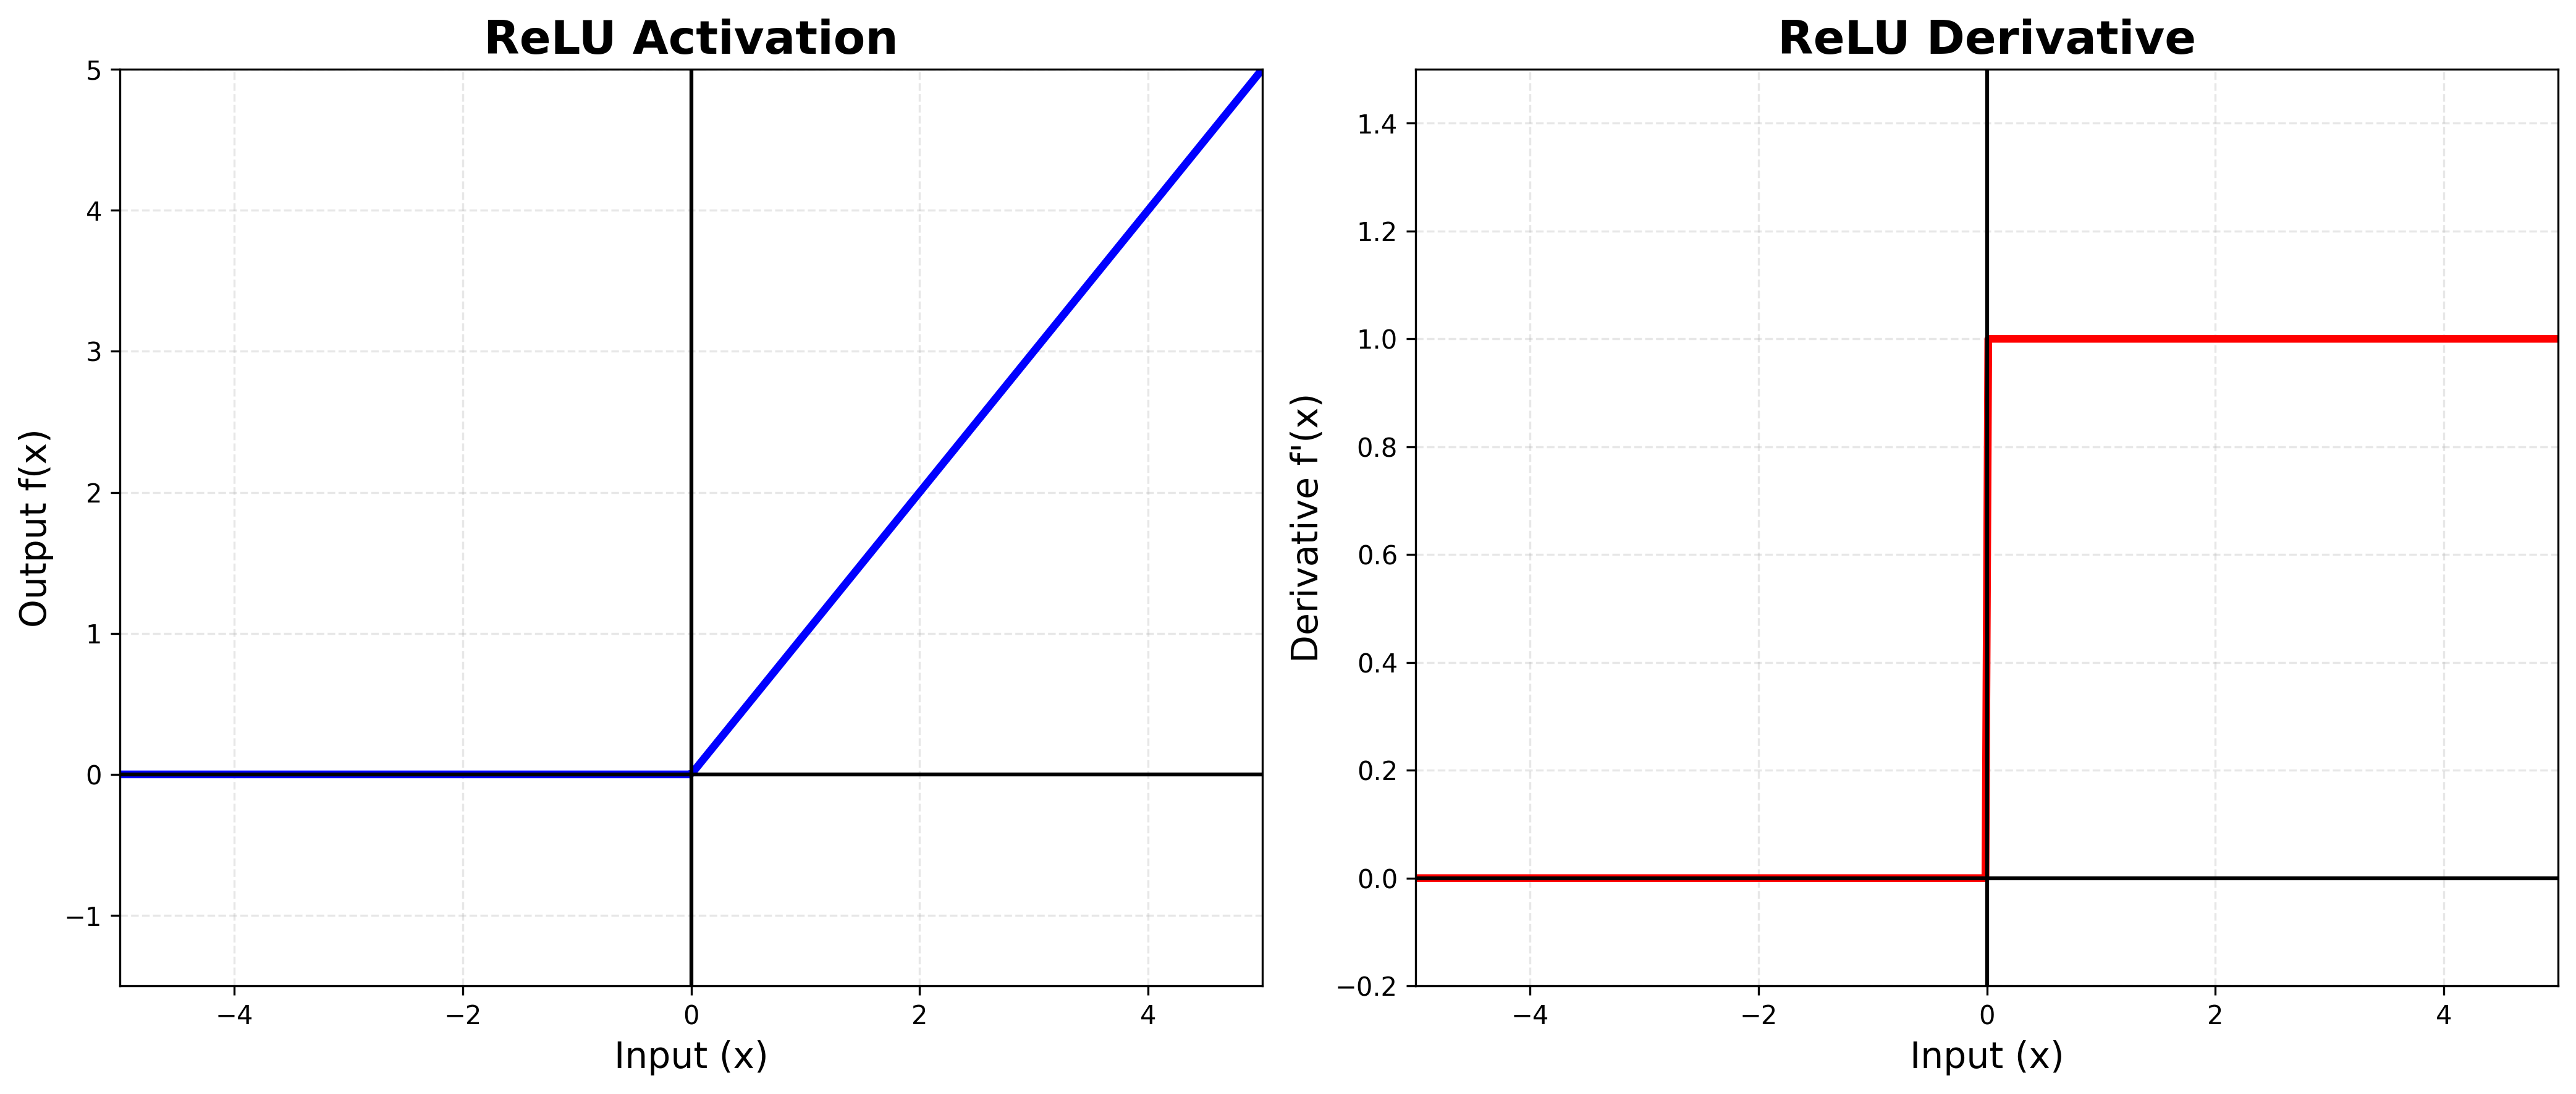

*   **Pros:** It is computationally cheap (just a simple threshold), which makes it highly efficient when deploying healthcare solutions on edge devices where processing power is limited. It also completely fixes the vanishing gradient problem for positive values.
*   **Cons:** "Dead Neurons." If a neuron's weights update in a way that causes it to only output negative numbers, ReLU will permanently turn it into a zero. That neuron dies and stops contributing to the network.

---

#### 4. Leaky ReLU
An upgraded ReLU designed specifically to fix the "Dying ReLU" problem by keeping a tiny, constant slope for negative values instead of a hard zero.

$$f(x)=\max(\alpha x,x)$$

*(where $\alpha$ is a small constant, e.g., $0.01$)*

**Derivative:**
$$f'(x)=\begin{cases}1&x>0\\\alpha&x\le0\end{cases}$$

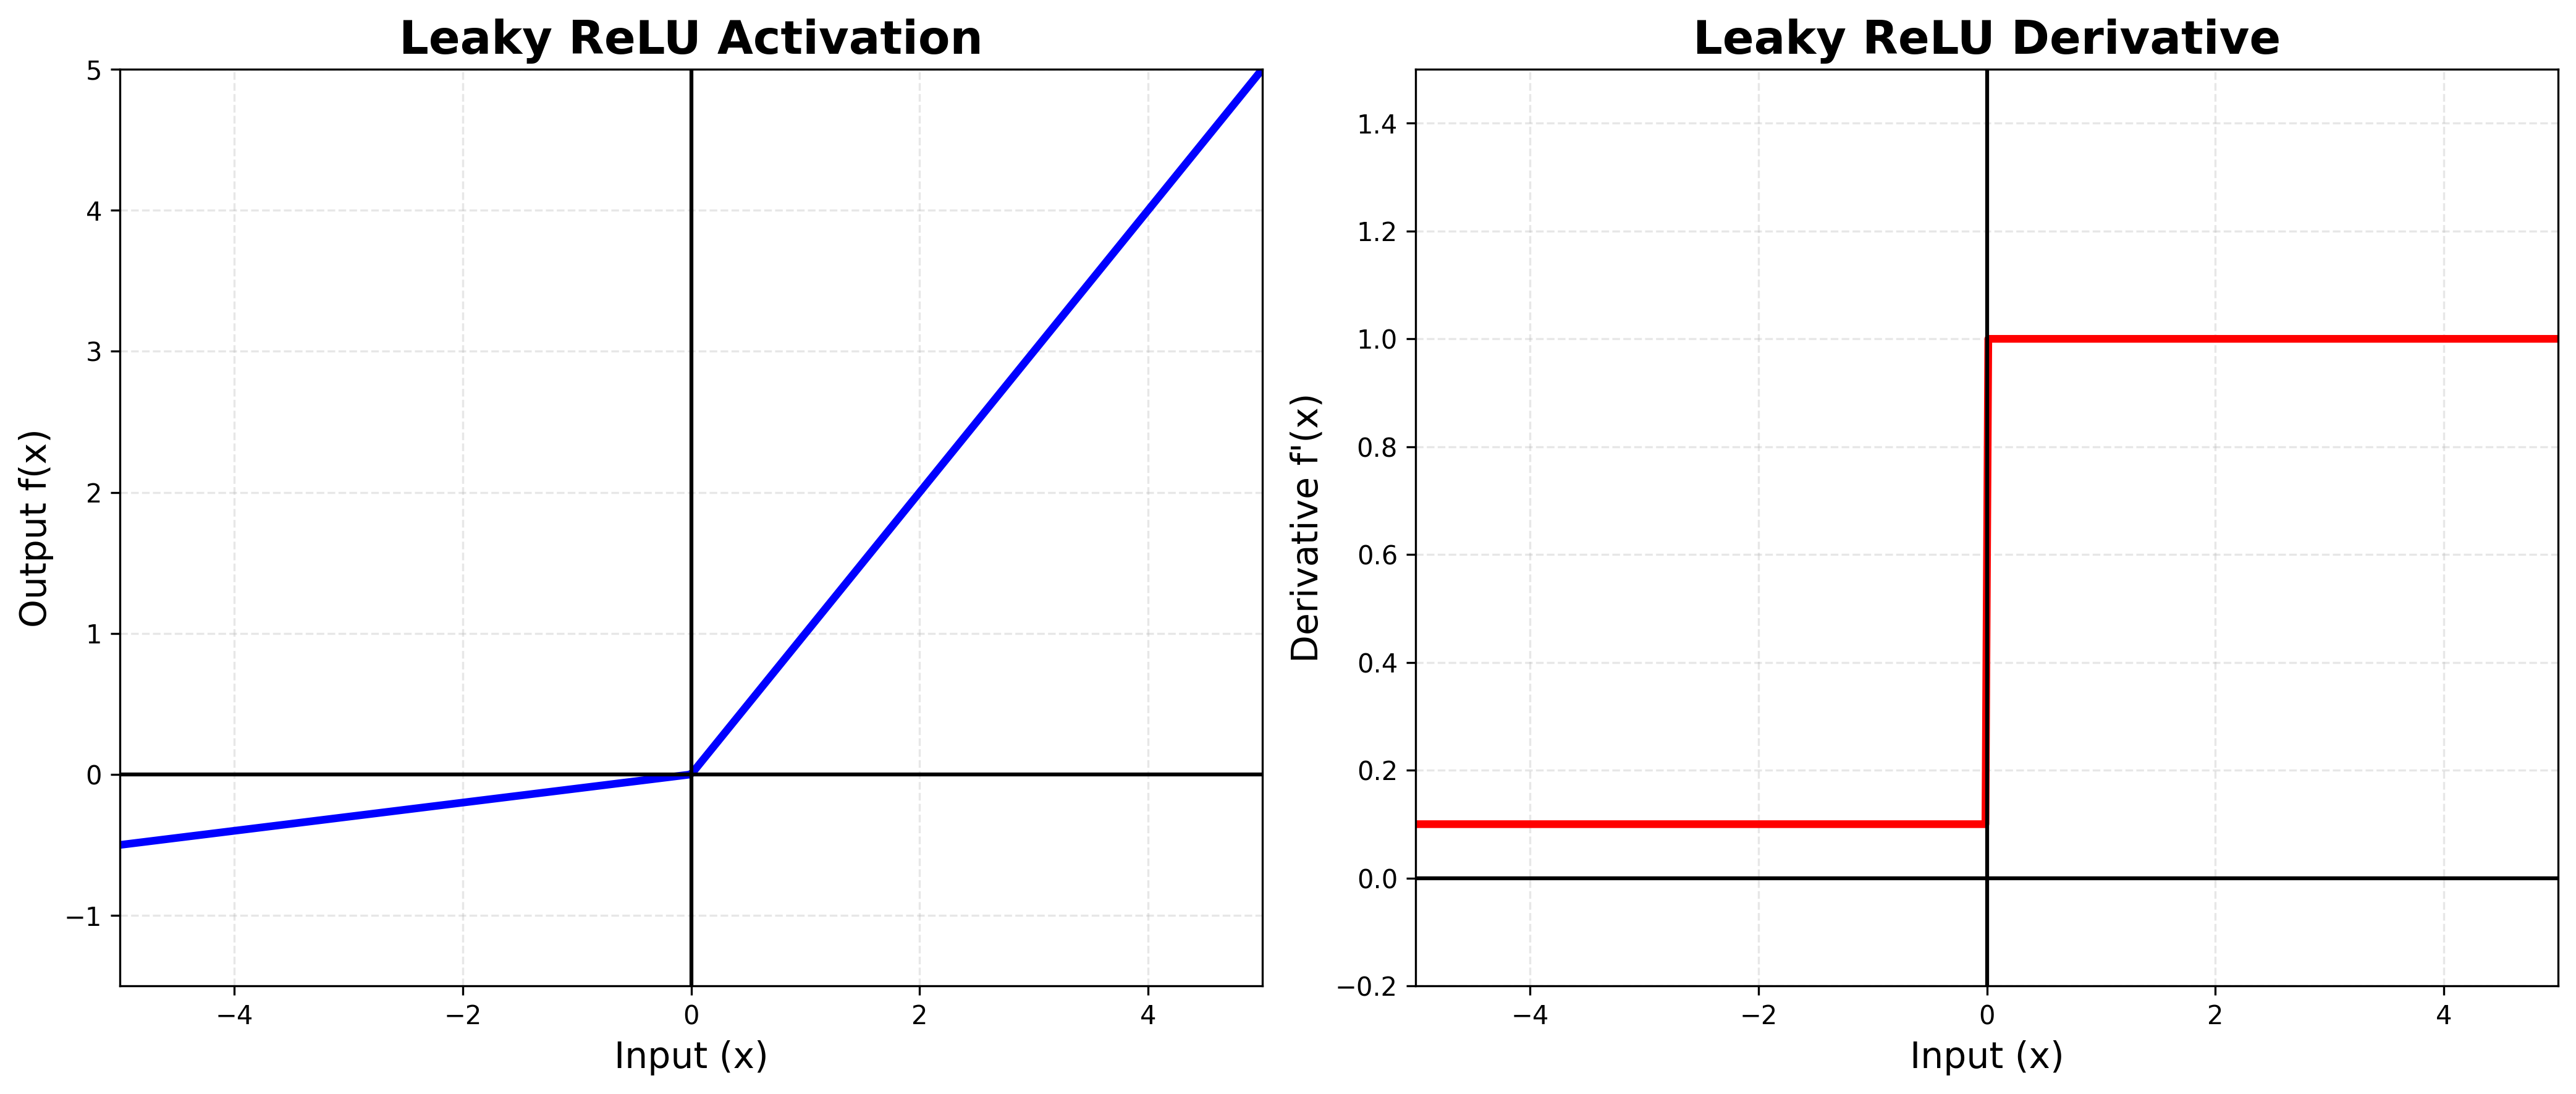

*   **Pros:** Prevents neuron death while maintaining the computational efficiency of standard ReLU.
*   **Cons:** The slope for negative values ($\alpha$) is a fixed hyperparameter that you must choose manually before training.

---

#### 5. ELU (Exponential Linear Unit)
Similar to ReLU, but instead of a sharp angular corner at zero, it transitions smoothly into negative values using an exponential curve.

$$f(x)=\begin{cases}x&x>0\\\alpha(e^x-1)&x\le0\end{cases}$$

**Derivative:**
$$f'(x)=\begin{cases}1&x>0\\\alpha e^x&x\le0\end{cases}$$

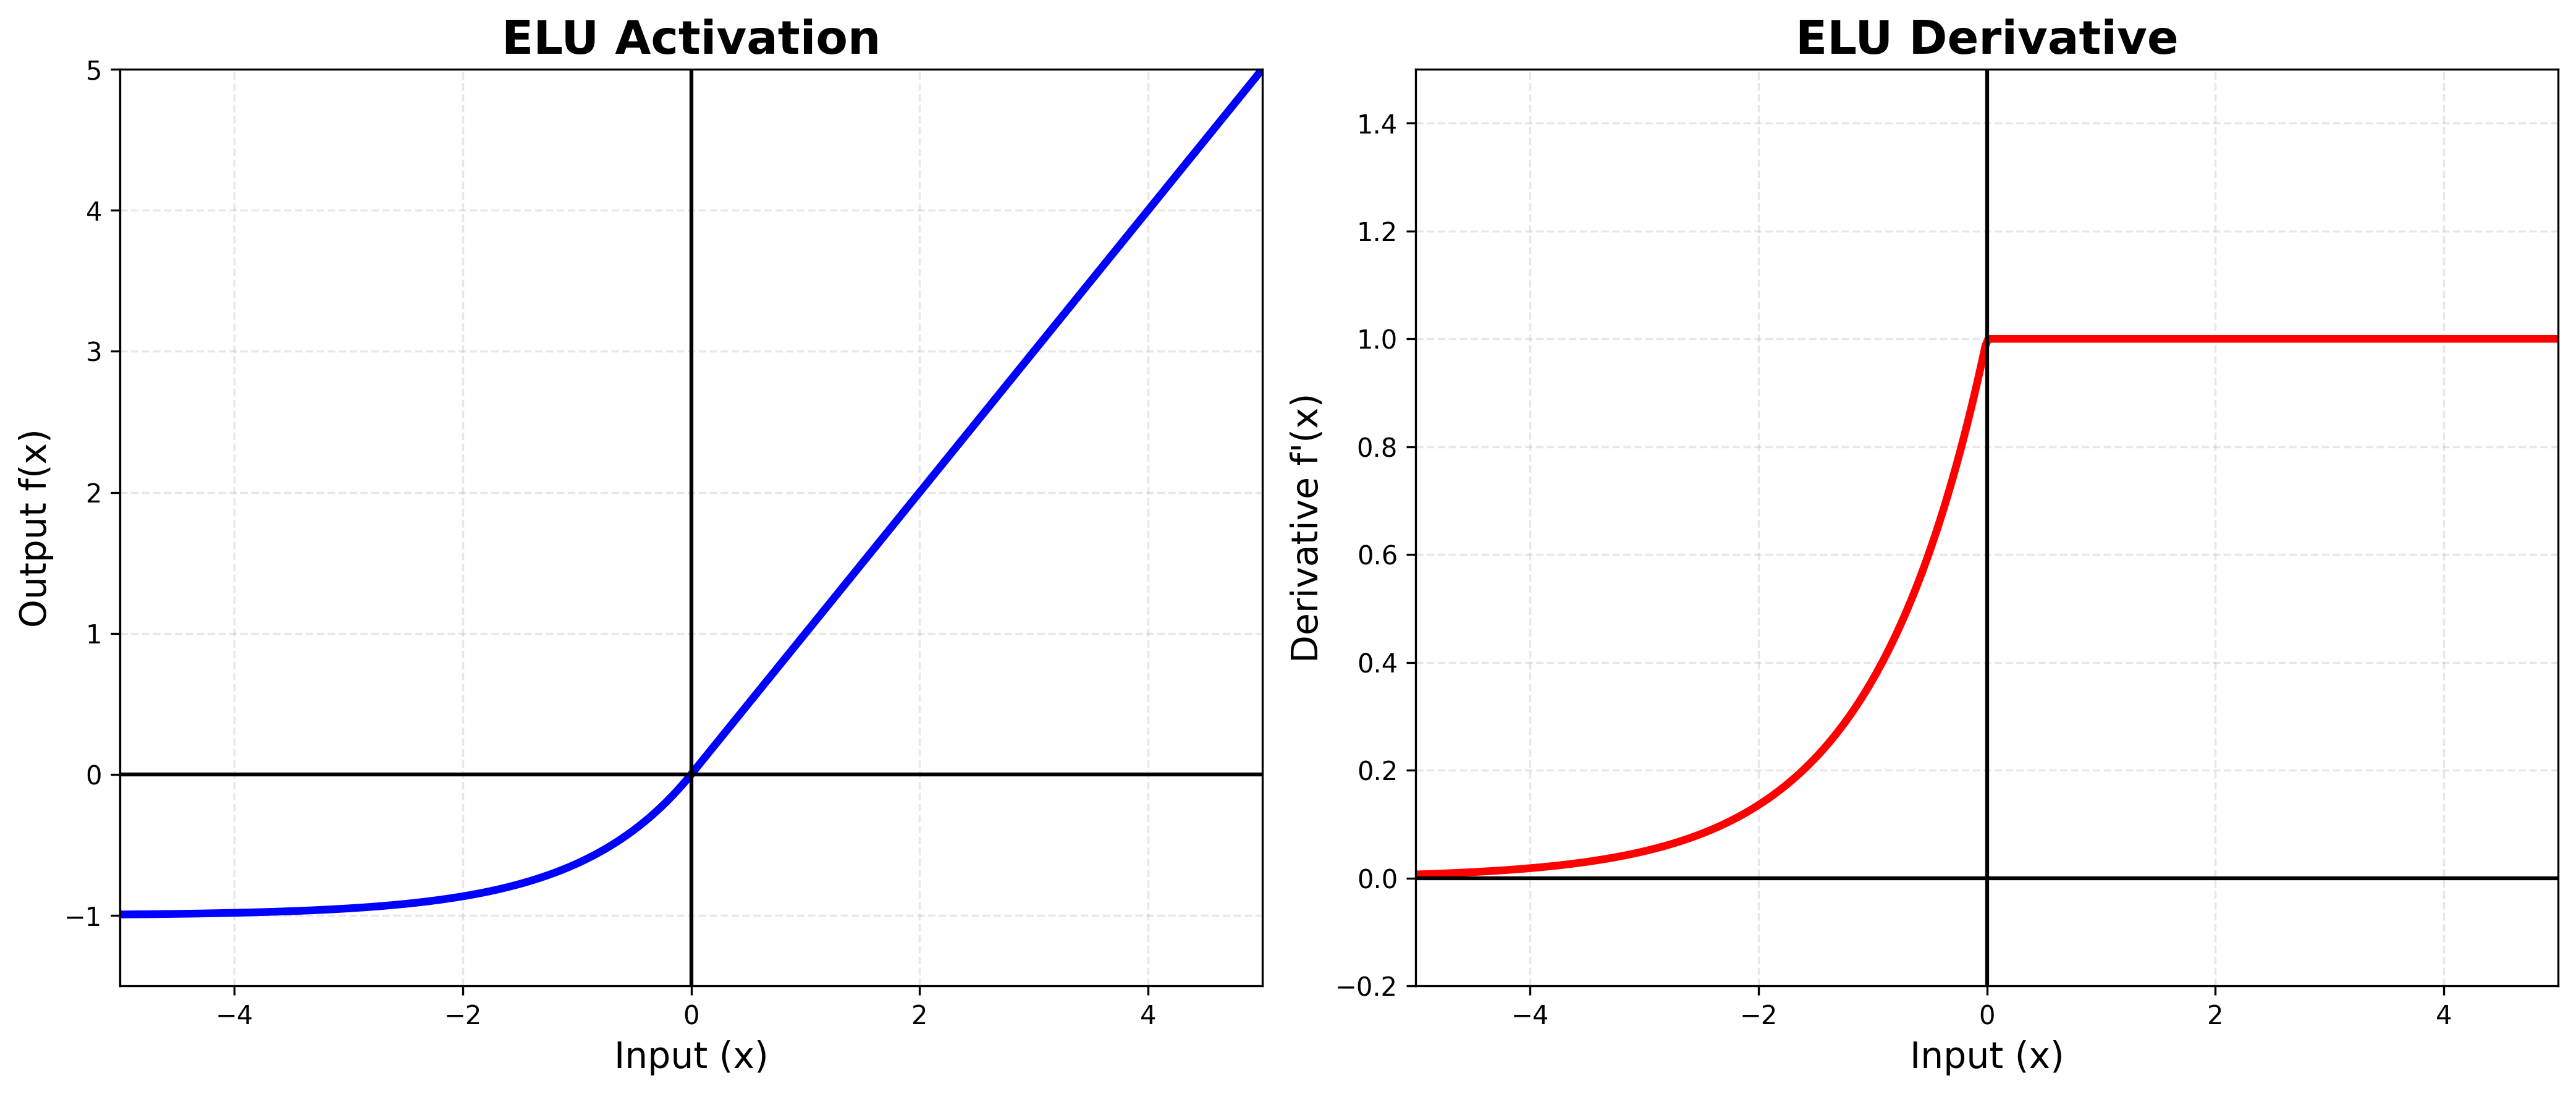

*   **Pros:** The smooth curve reduces noise during gradient updates, leading to faster convergence in deep networks.
*   **Cons:** Computing an exponential function ($e^x$) is computationally heavier than the simple maximum comparison used in ReLU.
---

#### 6. Swish / SiLU (Sigmoid Linear Unit)
A self-gated activation function that multiplies the input by its own Sigmoid activation. It is non-monotonic, meaning it dips slightly below zero before climbing back up.

$$f(x)=x\cdot\sigma(x)=\frac{x}{1+e^{-x}}$$

**Derivative:**
$$f'(x)=\sigma(x)+f(x)(1-\sigma(x))$$

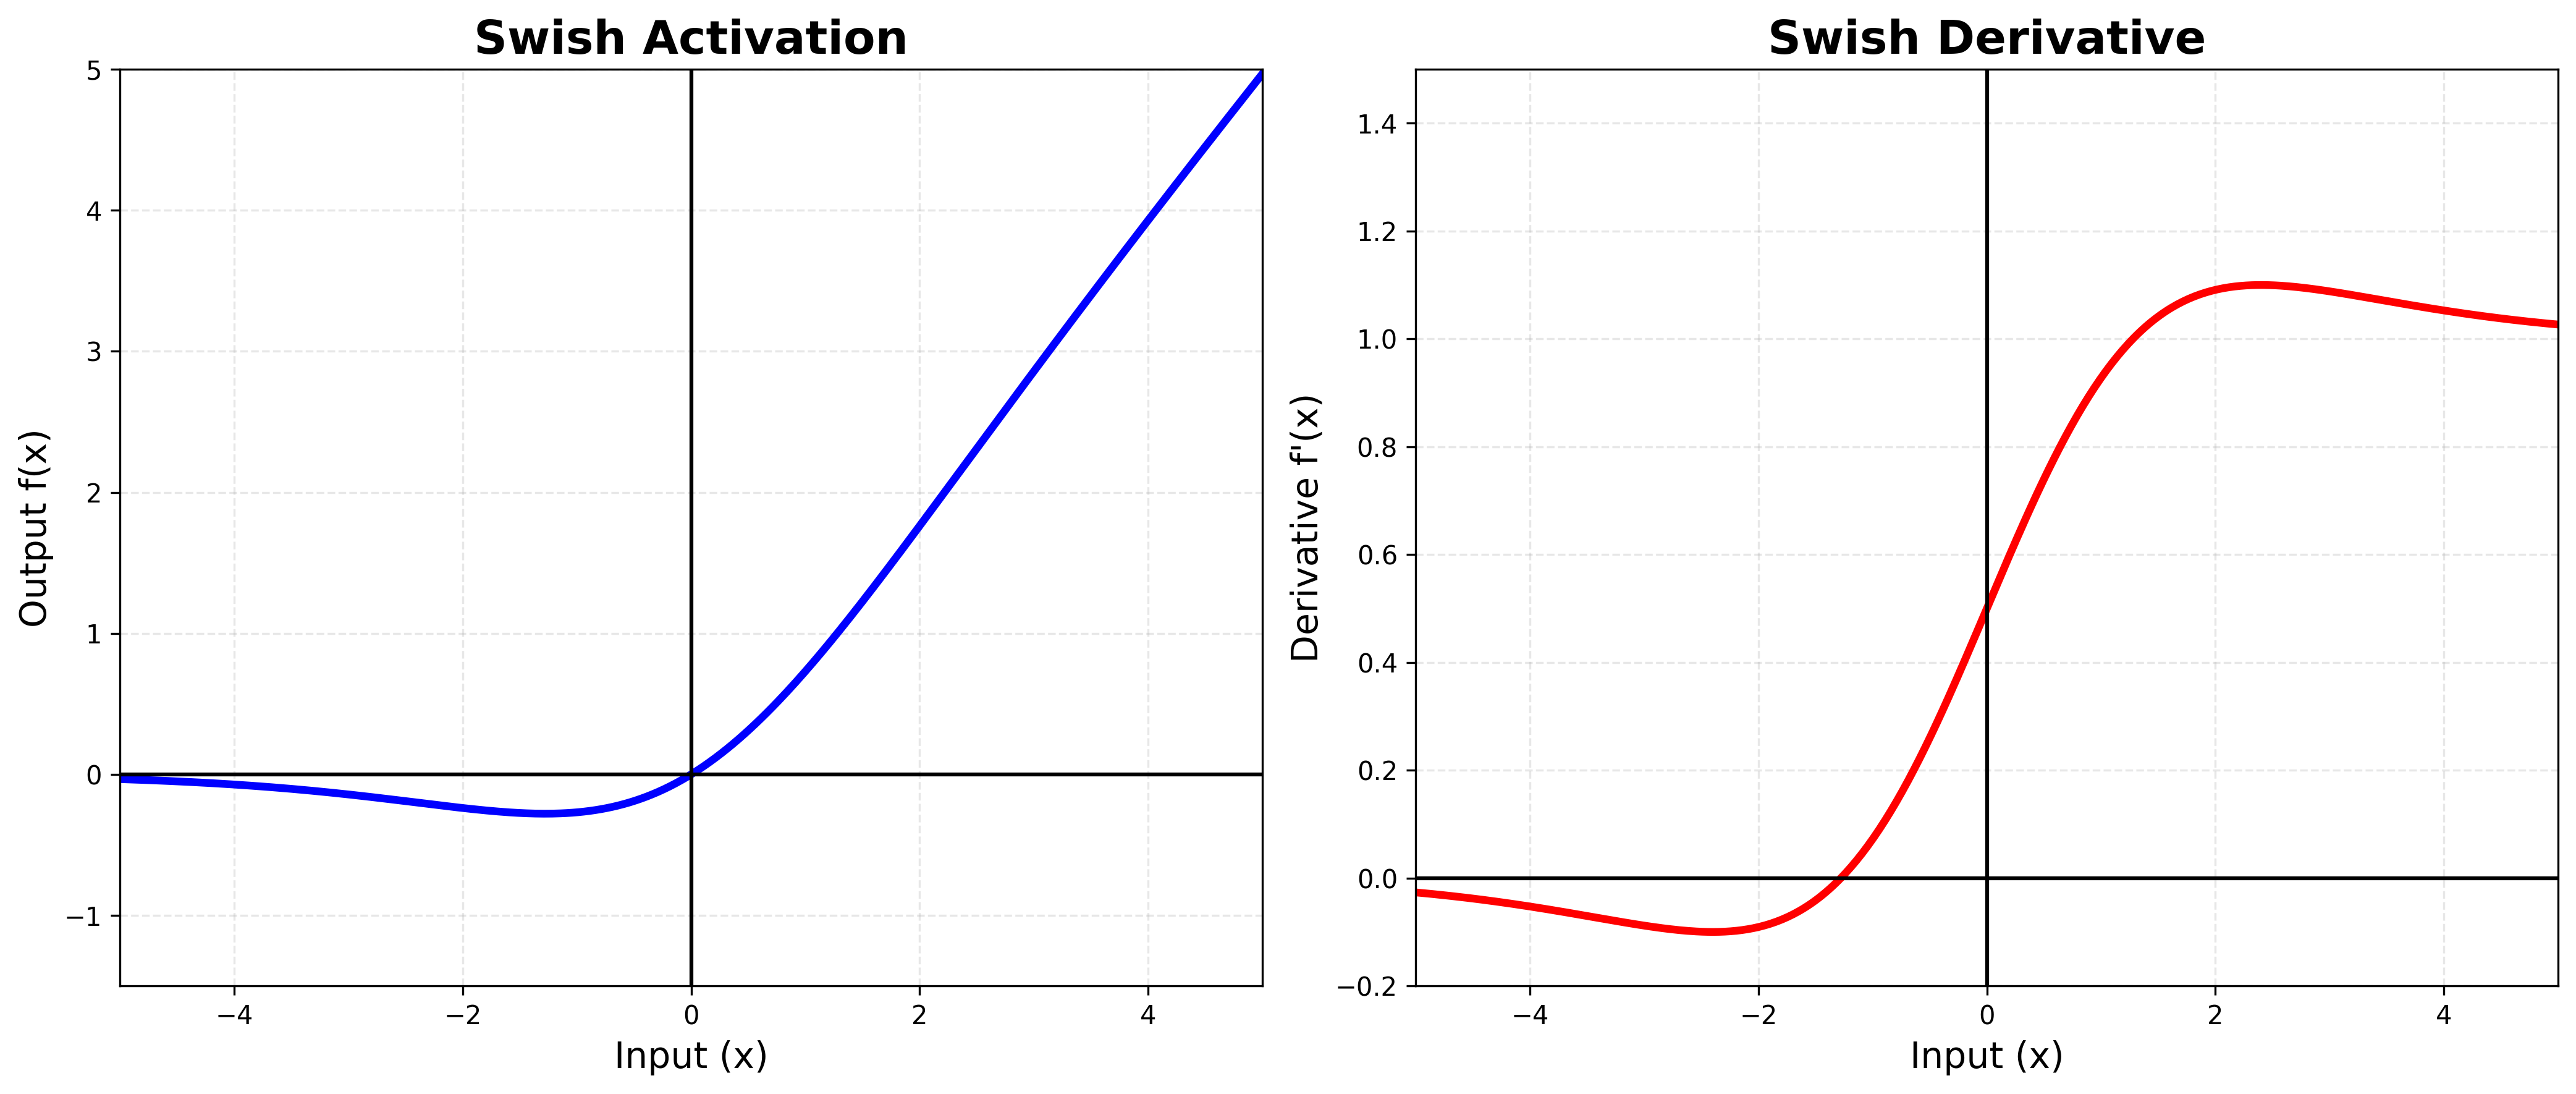

*   **Pros:** Consistently yields improvements in modern Convolutional Neural Networks (CNNs) and deep vision architectures. The slight negative dip preserves helpful structural information, making it excellent for complex computer vision tasks.
*   **Cons:** Higher computational cost compared to the ReLU family.
---

#### 7. GELU (Gaussian Error Linear Unit)
GELU scales the input by the probability of the input under a normal distribution, essentially weighting inputs by how likely they are to drop off to zero.

$$f(x)=x\cdot\Phi(x)$$

**Derivative:**
$$f'(x)=\Phi(x)+x\cdot\phi(x)$$

*(where $\Phi(x)$ is the cumulative distribution function and $\phi(x)$ is the probability density function of the normal distribution)*

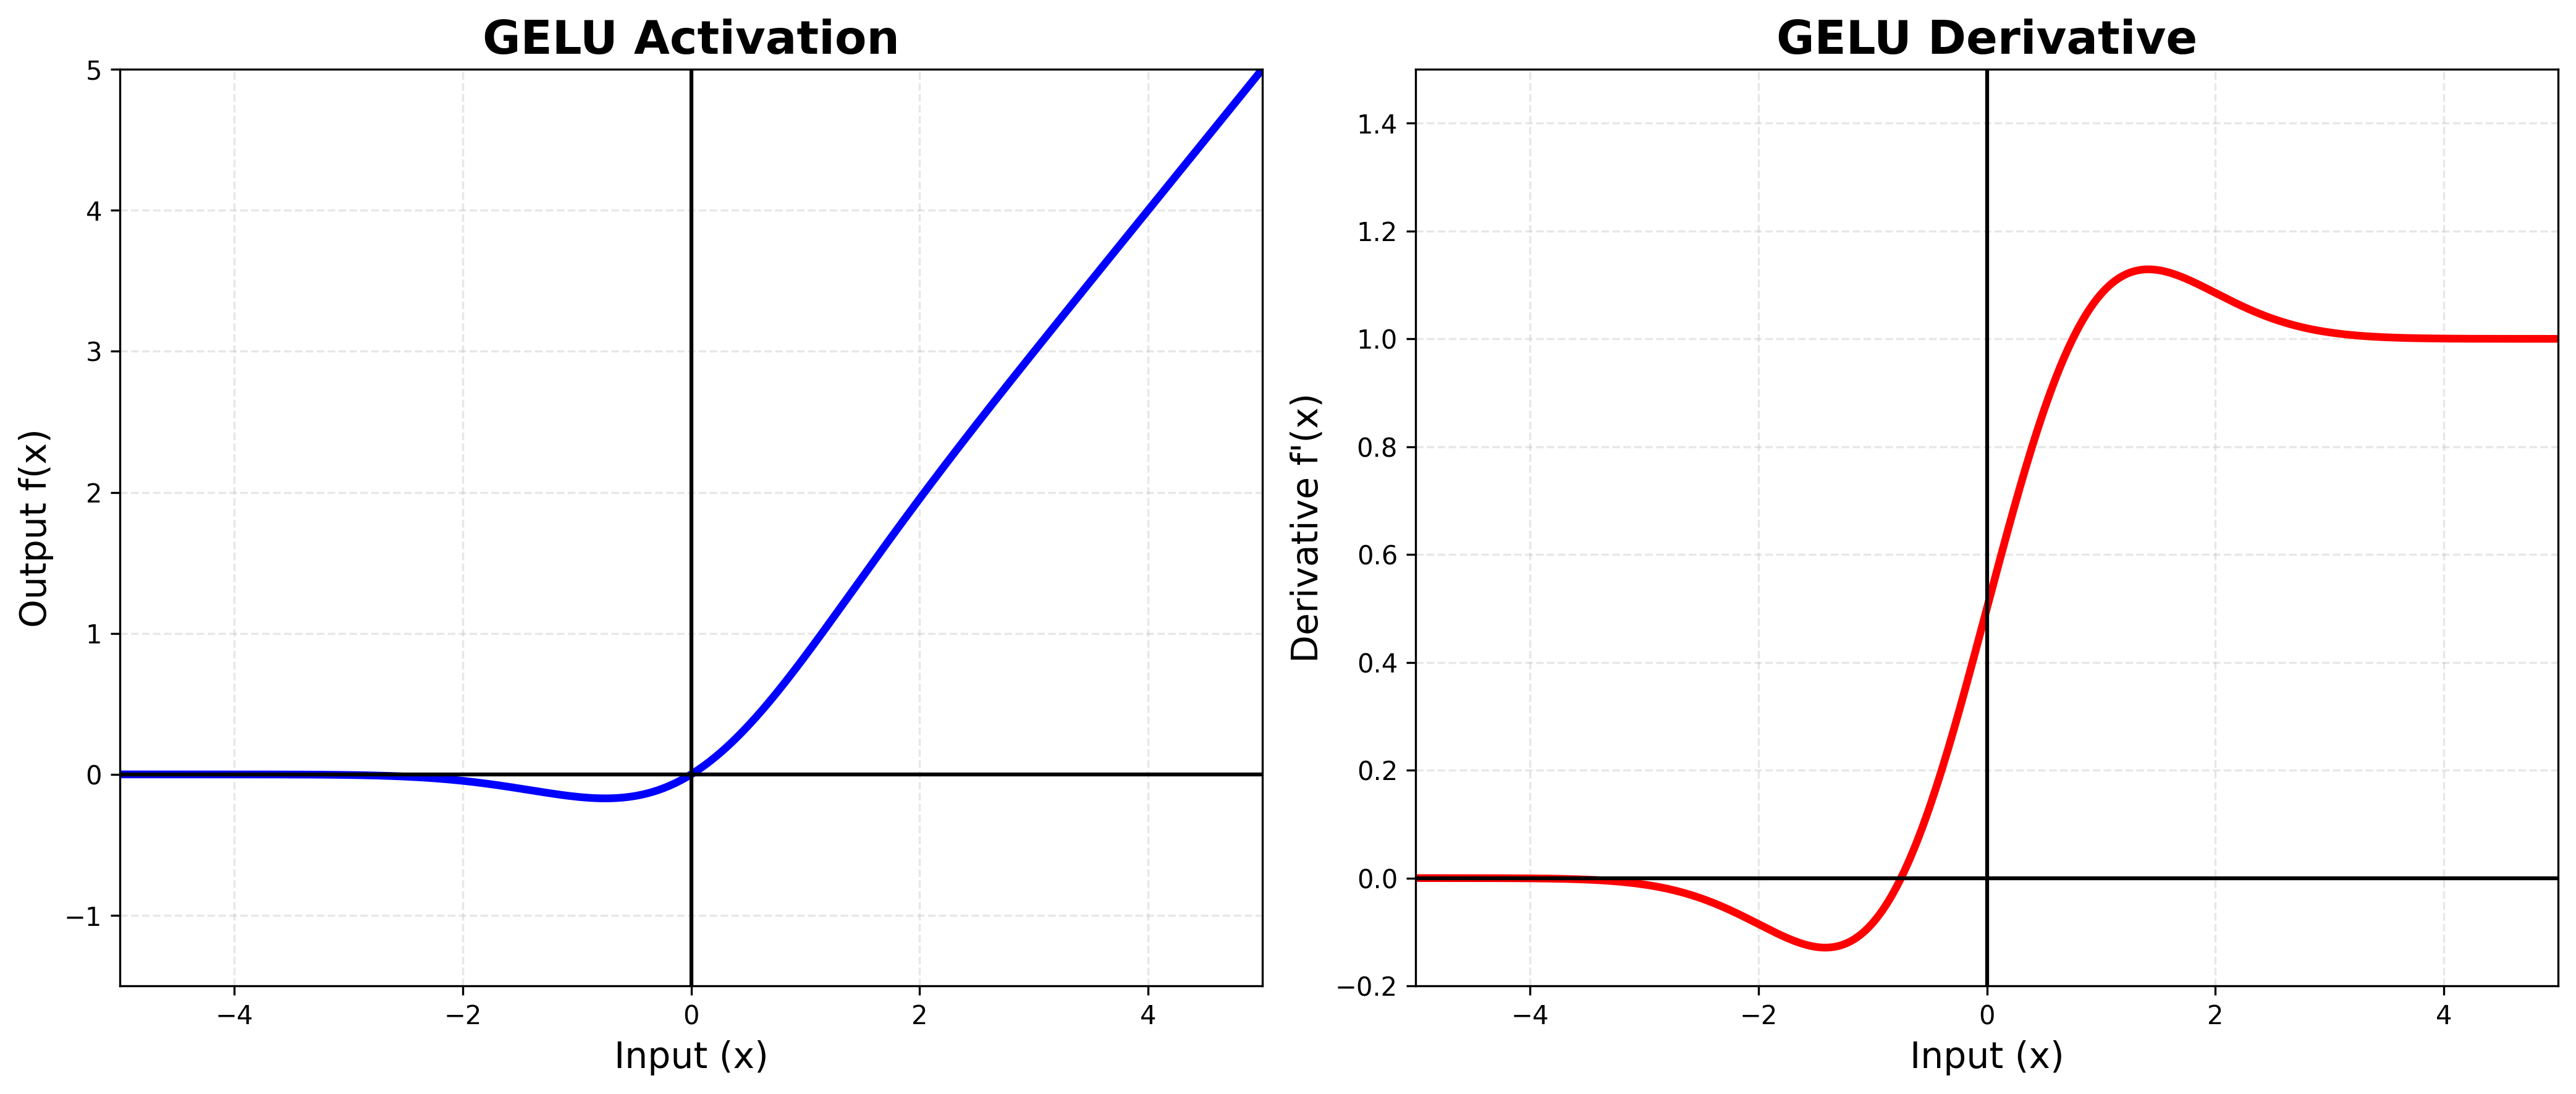

*   **Pros:** The industry standard for state-of-the-art architectures, particularly Vision-Language Models (VLMs) and Transformers.
*   **Cons:** Complex mathematical formulation that is heavily resource-intensive.
---

#### 8. Softmax (Output Layer Only)
Unlike the functions above that look at a single neuron in isolation, Softmax takes a vector of raw scores from an entire layer and converts them into a probability distribution that sums exactly to $1.0$.

$$f(x_i)=\frac{e^{x_i}}{\sum_{j}e^{x_j}}$$

**Derivative:**
$$\frac{\partial f(x_i)}{\partial x_j}=f(x_i)(\delta_{ij}-f(x_j))$$

*(where $\delta_{ij} = 1$ if $i = j$, and $0$ if $i \neq j$)*

*   **Pros:** The absolute necessity for the final output layer of a multi-class classification model (e.g., categorizing an image into one of five different disease stages).

## Multi-Layer Perceptrons

While a single perceptron is a great conceptual starting point, it has a fatal flaw: it can only learn linear boundaries. If your data cannot be separated by a straight line, a single neuron will completely fail.

To solve real-world problems, we must stack multiple neurons together to form a **Multi-Layer Perceptron (MLP)**. An MLP is a fully connected feedforward neural network. "Fully connected" means that every neuron in one layer connects to every single neuron in the next layer.

### *The Architecture of an MLP*
An MLP consists of three distinct types of layers:
1.  **Input Layer:** The raw data entering the network. The number of neurons here equals the number of features in your dataset.
2.  **Hidden Layers:** The processing engine of the network. A network can have one hidden layer or hundreds. This is where the activation functions create non-linearity.
3.  **Output Layer:** The final prediction. For binary classification, this is a single neuron. For multi-class classification, it contains multiple neurons representing probability scores.

### *Forward Propagation*

Forward propagation (often called the **forward pass**) is the core mechanism of how a neural network makes decisions. It is the chronological process of pushing input data from the input layer, through any hidden layers, to the final output layer to generate a prediction.

Think of it as an assembly line. Raw materials enter at the start, pass through several processing stations, and emerge as a finished product. For example, if we are building a simple classification model for a healthcare solution, our inputs ($X$) might be standardized patient metrics (like heart rate and blood pressure), and the output ($y$) is the network's prediction of a specific risk category.

#### The Two Steps of a Forward Pass

Inside every single artificial neuron during the forward pass, two sequential mathematical operations occur.

#### 1. The Linear Transformation (The Weighted Sum)

The neuron receives inputs from the previous layer, multiplies each input by its corresponding weight, and adds a bias.

For a **single neuron**, this operation is:

$$
z = W \cdot X + b
$$

Where:

- $X$: The input vector (the data we are feeding in).
- $W$: The weights (determining how important each input is).
- $b$: The bias (a baseline adjustment).
- $z$: The weighted sum before applying an activation function.

#### 2. The Activation (The Non-Linearity)

If we only used the linear transformation above, our network would just be a simple linear regression model. To allow the network to learn complex, real-world patterns, we pass the weighted sum ($z$) through an **activation function** ($f$):

$$
a = f(z)
$$

Where:

- $a$: The final output (activation) of this specific neuron, which is then sent forward to become the input for the next layer.

#### *Forward Propagation in a Multi-Layer Perceptron (MLP)*

The equations above describe what happens inside **one neuron**. However, an MLP contains many neurons connected together. Calculating every neuron one at a time using Python `for` loops would be extremely slow.

Instead, we use **Linear Algebra (Vectorization)** to compute all neurons in a layer simultaneously using matrix operations.

For any hidden layer $l$, forward propagation consists of the same two steps, but now performed on entire matrices instead of individual values.

##### 1. The Linear Transformation

$$
Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]}
$$

##### 2. The Activation

$$
A^{[l]} = g^{[l]}(Z^{[l]})
$$

#### Breaking Down the Variables

- $l$: The current layer being computed.
- $W^{[l]}$: The **weight matrix** for layer $l$. If the current layer has 5 neurons and the previous layer has 3 neurons, then $W^{[l]}$ is a $5 \times 3$ matrix containing all the learnable weights.
- $A^{[l-1]}$: The **activation vector** from the previous layer. For the first hidden layer, $A^{[0]} = X$, the input data.
- $b^{[l]}$: The **bias vector** for the current layer.
- $Z^{[l]}$: The vector of weighted sums for every neuron in the current layer.
- $g^{[l]}$: The activation function (such as ReLU or Sigmoid).
- $A^{[l]}$: The output (activation) of the current layer, which immediately becomes the input to the next layer.


During a forward pass, the same two-step process repeats through every layer of the network:

1. The input data $X$ enters the network.
2. Layer 1 computes
   $$
   Z^{[1]} = W^{[1]}A^{[0]} + b^{[1]}
   $$
   and then
   $$
   A^{[1]} = g^{[1]}(Z^{[1]}).
   $$
3. Layer 2 uses $A^{[1]}$ as its input, computes
   $$
   Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]},
   $$
   and then
   $$
   A^{[2]} = g^{[2]}(Z^{[2]}).
   $$
4. This process continues layer by layer until the final output layer produces the network's prediction, $\hat{y}$.

By stacking these linear transformations and applying non-linear activation functions between them, an MLP can learn highly complex relationships between inputs and outputs that cannot be represented by a simple linear model.

> **Important Note:** During forward propagation, **no learning actually happens**. The network is simply making a "guess" based on whatever its weights and biases currently are. To actually learn, we need to evaluate that guess and update the weights, which brings us to loss functions and backpropagation.

Lets implement a MLP that we can use to solve our XOR problem earlier.

In [17]:
# Lets work with tanh activation function
def relu(x):
    return np.maximum(0,x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


input_neurons = train_x.shape[1]
hidden_neurons = 4
output_neurons = 1

# We randomly initialize weights and biases
W1 = np.random.uniform(-1, 1, (input_neurons, hidden_neurons))
b1 = np.zeros((1, hidden_neurons))

W2 = np.random.uniform(-1, 1, (hidden_neurons, output_neurons))
b2 = np.zeros((1, output_neurons))
# We randomly initialize weights and biases
W1 = np.random.uniform(-1, 1, (input_neurons, hidden_neurons))
b1 = np.zeros((1, hidden_neurons))

W2 = np.random.uniform(-1, 1, (hidden_neurons, output_neurons))
b2 = np.zeros((1, output_neurons))
print(W2.shape)

(4, 1)


In [18]:
#Forward Pass
Z1 = np.dot(train_x, W1) + b1

A1 = relu(Z1)
print(f"Shape of Hidden Layer Output (A1): {A1.shape} -> (5 samples, 4 hidden neurons)")
Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)
print(f"Shape of Final Output (A2): {A2.shape} -> (5 samples, 1 prediction each)\n")
correct_predictions = 0

for i in range(len(A2)):
    raw_prediction = A2[i][0]

    # We output 1 or -1 to match the format of our true labels
    predicted_class = 1 if raw_prediction >= 0.5 else -1
    true_class = train_labels[i][0] if train_labels.ndim == 2 else train_labels[i]
    # Check if the prediction is correct
    is_correct = predicted_class == true_class
    if is_correct:
        correct_predictions += 1
        status = " Correct"
    else:

        status = "Incorrect"
    print(
        f"Sample {i+1:2d} | "
        f"Raw Output: {raw_prediction:7.4f} | "
        f"Predicted: {predicted_class:2d} | "
        f"True Label: {true_class:2d} | "
        f"{status}"
    )

# Calculate and print the accuracy
accuracy = (correct_predictions / len(A2)) * 100
print("-" * 90)
print(f"Correct Predictions : {correct_predictions}/{len(A2)}")
print(f"Training Accuracy   : {accuracy:.2f}%")

Shape of Hidden Layer Output (A1): (80, 4) -> (5 samples, 4 hidden neurons)
Shape of Final Output (A2): (80, 1) -> (5 samples, 1 prediction each)

Sample  1 | Raw Output:  0.1115 | Predicted: -1 | True Label:  1 | Incorrect
Sample  2 | Raw Output:  0.0907 | Predicted: -1 | True Label:  1 | Incorrect
Sample  3 | Raw Output:  0.4606 | Predicted: -1 | True Label: -1 |  Correct
Sample  4 | Raw Output:  0.4381 | Predicted: -1 | True Label: -1 |  Correct
Sample  5 | Raw Output:  0.5000 | Predicted:  1 | True Label: -1 | Incorrect
Sample  6 | Raw Output:  0.2156 | Predicted: -1 | True Label:  1 | Incorrect
Sample  7 | Raw Output:  0.1867 | Predicted: -1 | True Label:  1 | Incorrect
Sample  8 | Raw Output:  0.0636 | Predicted: -1 | True Label:  1 | Incorrect
Sample  9 | Raw Output:  0.5000 | Predicted:  1 | True Label: -1 | Incorrect
Sample 10 | Raw Output:  0.3875 | Predicted: -1 | True Label:  1 | Incorrect
Sample 11 | Raw Output:  0.5000 | Predicted:  1 | True Label: -1 | Incorrect
Sample 1

After performing the forward pass, the network produces an output for every training sample.
> Note the network , **has not actually learned anything**.

The weights and biases were initialized randomly:

$$
W^{[1]},\; b^{[1]},\; W^{[2]},\; b^{[2]}.
$$

During the forward pass, the network simply used these random parameters to compute predictions. No optimization has taken place. No weights have been updated.No information from the training labels has been used to improve the model. The network simply made its best "guess" using its current parameters.

In this particular example, the random initialization happened to produce predictions that match most of the training labels. This is possible for small datasets and should not be interpreted as evidence that the model has learned a meaningful decision boundary.



### *Loss Functions*

In the previous stage (**forward propagation**), our neural network processed the input data and produced a prediction. However, simply making a prediction is not enough. We need a way to determine **how good or bad that prediction is**.

A **loss function** (also called a **cost function** or **error function**) is a mathematical function that measures how far the network's predictions are from the true labels in the training dataset.

Think of forward propagation as a student taking an exam. The network answers every question by making predictions. The loss function then acts as the teacher grading the exam, assigning a numerical score that represents how many mistakes the student made.

The primary objective of training a neural network is therefore simple:

> **Find the weights and biases that minimize the loss function.**

A smaller loss indicates that the network's predictions are closer to the correct answers, while a larger loss indicates that the predictions are farther from the true labels.
Unlike accuracy, which simply tells us whether a prediction is correct or incorrect, a loss function measures **how wrong** a prediction is. For example, suppose the true label is
$$y = 1.$$ If the network predicts $$\hat{y}=0.95,$$ then the prediction is very close to the correct answer, so the loss will be small. On the other hand, if the network predicts$$\hat{y}=-0.90,$$ the prediction is far from the true label, resulting in a much larger loss.
This additional information is extremely valuable because it tells the network not only **whether** it made a mistake, but also **how severe** that mistake was.
Mathematically, the training objective is expressed as

$$
\min_{W,b} L(y,\hat{y}),
$$

where

- $W$ represents the network's weights,
- $b$ represents the network's biases,
- $y$ is the true label,
- $\hat{y}$ is the predicted output,
- $L(y,\hat{y})$ is the loss function.

The goal of learning is to find the set of weights and biases that minimizes this loss.

#### *Common Types of Loss Functions*

The choice of loss function depends entirely on the type of machine learning problem being solved. Different tasks require different ways of measuring prediction error.


##### 1. Mean Squared Error (MSE)

Mean Squared Error (MSE) is primarily used for **regression problems**, where the objective is to predict continuous numerical values such as house prices, temperatures, or stock prices.

The Mean Squared Error is defined as

$$
MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

where

- $n$ is the number of training samples,
- $y_i$ is the true value,
- $\hat{y}_i$ is the predicted value.

The squared difference ensures that positive and negative errors do not cancel each other out. It also penalizes large prediction errors much more heavily than small ones, encouraging the model to avoid making predictions that are far from the true values.


##### 2. Cross-Entropy Loss

Cross-Entropy Loss is commonly used for **classification problems**, where the objective is to assign an input to one of several discrete classes.

Examples include:
- Binary classification (spam vs. not spam)
- Disease diagnosis (positive vs. negative)
- Image classification (cat vs. dog)
Instead of measuring the raw numerical distance between predictions and targets like MSE, Cross-Entropy measures how well the predicted probability distribution matches the true class labels.
Because neural networks used for classification often output probabilities (using activation functions such as **Sigmoid** or **Softmax**), Cross-Entropy evaluates how close the predicted probability (a value between 0 and 1) is to the actual true class.
For example, suppose the true class is **1**, but the network predicts a probability of **0.01**. The model is extremely confident, but confidently wrong. Cross-Entropy assigns a very large penalty in this situation. Conversely, if the model predicts a probability close to **1** for the correct class, the loss becomes very small.

**Binary Cross-Entropy (BCE) — For Binary Classification**
When your network needs to make a yes/no decision—such as classifying whether a medical scan shows a specific anomaly ($1$) or not ($0$)—you use the Binary Cross-Entropy formula.
Mathematically, it is defined as:
$$
BCE = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$

where:
* $N$ is the total number of samples.
* $y_i$ is the true label ($0$ or $1$).
* $\hat{y}_i$ is the predicted probability for the positive class.
**How the formula works:**
* If the true class $y_i$ is $1$, the second half of the equation $(1-1=0)$ drops out, leaving $-y_i\log(\hat{y}_i)$. The loss strictly penalizes the network if the predicted probability $\hat{y}_i$ is close to $0$.
* If the true class $y_i$ is $0$, the first half of the equation drops out, leaving $-(1-y_i)\log(1-\hat{y}_i)$. This penalizes the network if it confidently predicts a $1$.

##### 3. Categorical Cross-Entropy - For Multi-Class Classification
In some applications such as in healthcare there maybe a need to categorize data into more than two distinct classes (e.g., diagnosing a scan as Stage 1, Stage 2, or Stage 3), this extension of BCE is used. It is almost always paired with the Softmax activation function in the final layer.

$$CCE=-\sum_{i=1}^{C}y_i\log(\hat{y}_i)$$

*   $C$: The total number of classes.
*   $y_i$: A binary indicator ($0$ or $1$) representing if class label $i$ is the correct ground-truth classification.
*   $\hat{y}_i$: The predicted probability for class $i$.

In [19]:
#Implementation of binary cross entropy
def binary_cross_entropy(y_true, y_pred):

    # Clip y_pred to prevent log(0) errors.
    # Epsilon is a tiny number close to zero.
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Calculate the BCE loss using the clipped predictions
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss



To truly understand how a neural network learns, it helps to visualize the "Error Landscape."

In the plot above, we took our two weights ($W_1$ and $W_2$) and tested 2,500 different combinations ranging from -5 to 5. For every single combination, we ran a forward pass on our dataset and calculated the total **Binary Cross-Entropy (BCE) Loss**. We then plotted that loss on the Z-axis (height).

#### *Loss landscape plot:*
* **The High Slopes (Yellow/Green):** If our randomly initialized weights land here, the network has a very high error. It is making poor predictions.
* **The Valley (Dark Purple):** This is the **Global Minimum**. The coordinates at the very bottom of this bowl represent the optimal values for $W_1$ and $W_2$ where the network makes the fewest mistakes.

When we initialize a network with random weights, we are essentially dropping a point somewhere on the high edges of this bowl.

**The goal of training is to find our way to the bottom.** However, the network cannot "see" the whole bowl like we can. It can only feel the slope directly beneath its feet. To get to the bottom, it must calculate the slope and take a step downhill—a mathematical process known as **Gradient Descent**.

### *Backpropagation*

Backpropagation is the learning algorithm that enables a neural network to improve its predictions over time. It works by propagating the error from the output layer back through the hidden layers, computing how much each weight and bias contributed to the overall loss.
Think of the training process as a sequence of four steps:

1. Perform **forward propagation** to compute the network's predictions.
2. Compute the **loss function** to measure how wrong the predictions are.
3. Use **backpropagation** to calculate the gradients of the loss with respect to every weight and bias.
4. Update the weights and biases so that the network makes better predictions during the next forward pass.

This cycle is repeated many times until the loss becomes sufficiently small or the model converges.
Backpropagation is based on one of the most important concepts in calculus: the **gradient**.
A gradient measures how much the loss changes when one of the network's parameters changes by a small amount.
For a weight \(W\), the gradient is written as

$$
\frac{\partial L}{\partial W},
$$

where

- \(L\) is the loss function.
- \(W\) is one of the network's weights.

The gradient tells us two important pieces of information:

- **Direction:** Should the weight increase or decrease?
- **Magnitude:** How much does this weight influence the loss?

Large gradients indicate that changing the weight has a significant effect on the loss, while small gradients indicate that the weight has relatively little influence.
Backpropagation computes these gradients efficiently for every weight and bias in the network using the **chain rule of calculus**.
If we want to know how much a specific weight ($w$) in an early layer impacted the final Loss ($L$), we can't calculate it directly. Instead, we multiply the cascading effects of everything that happened in between.

For a simple single-neuron output, the Chain Rule looks like this:

$$\frac{\partial L}{\partial w}=\frac{\partial L}{\partial a}\cdot\frac{\partial a}{\partial z}\cdot\frac{\partial z}{\partial w}$$

*   $\frac{\partial L}{\partial a}$: How did the final activation output affect the loss?
*   $\frac{\partial a}{\partial z}$: How did the raw weighted sum affect the activation output? (This is the derivative of the activation function).
*   $\frac{\partial z}{\partial w}$: How did the specific weight affect the raw sum?
*   $\frac{\partial L}{\partial w}$: The final gradient! This tells the optimizer exactly how to adjust this specific weight to lower the loss.

#### Automatic Differentiation (AutoGrad)
If you were building neural networks in the 1990s or 2000s, you had to calculate all of these derivatives by hand and hardcode the calculus into your scripts. For a modern Deep Neural Network with millions of parameters, doing this by hand is mathematically impossible.

Today, we use **Automatic Differentiation** (often called **AutoGrad** in frameworks like PyTorch).

Here is how AutoGrad acts like magic behind the scenes:
1.  **The Computational Graph:** During the forward pass, the framework doesn't just calculate numbers; it builds a map (a Directed Acyclic Graph). It remembers every single tensor, every matrix multiplication, and every activation function used.
2.  **The Tape Recorder:** Think of it like a tape recorder that records the exact sequence of mathematical operations.
3.  **The Backward Pass:** When you call a command like `loss.backward()` in PyTorch, AutoGrad hits "rewind." It traverses the computational graph backward, automatically applying the Chain Rule to compute the exact gradients for every single weight in the network simultaneously.

Thanks to Automatic Differentiation, developers can focus entirely on designing the architecture of the network without ever having to manually derive complex matrix calculus!
However, computing the gradients alone does not improve the model.
The gradients simply tell us **how** the parameters should change.
The actual process of changing the parameters is performed by an **optimizer**.

### *Optimizers*

Once backpropagation has computed the gradients, the network must update its weights and biases.

This is the job of the **optimizer**.

Think of training a neural network like a blindfolded hiker trying to find the lowest point in a vast, hilly valley.

- The hiker's current altitude represents the **loss**.
- Feeling the slope beneath their feet represents **backpropagation**, which computes the gradients.
- Deciding how far to step downhill represents the **optimizer**, which updates the model parameters.

The objective is always the same:

> **Take a step that reduces the loss.**

### *Gradient Descent*

The most fundamental optimization algorithm is **Gradient Descent**.
After backpropagation computes the gradient, Gradient Descent updates each weight using the following equation:
$$
W_{\text{new}} = W_{\text{old}} - \alpha \frac{\partial L}{\partial W}
$$

where

- \(W_{\text{old}}\) is the current weight.
- \(W_{\text{new}}\) is the updated weight.
- \(\frac{\partial L}{\partial W}\) is the gradient computed during backpropagation.
- \(\alpha\) is the **learning rate**.

Notice the subtraction in the equation.

The gradient points in the direction where the loss increases the fastest. Since our objective is to minimize the loss, we move in the opposite direction of the gradient.
This process is repeated for every weight and bias in the network.
The learning rate, denoted by
$$
\alpha,
$$
is one of the most important hyperparameters in deep learning.It determines the size of each update during training.Choosing an appropriate learning rate is critical.

##### Learning Rate Too Large

If the learning rate is too large, the optimizer takes very large steps.
Instead of moving smoothly toward the minimum loss, it may overshoot the optimum and continually bounce around without converging.
As a result, training becomes unstable and the model may fail to learn.
##### Learning Rate Too Small

If the learning rate is too small, the optimizer takes extremely small steps. Although the model may eventually converge, training becomes very slow and may require an impractical number of iterations.
The ideal learning rate is large enough to allow rapid learning while remaining small enough to ensure stable convergence.


### *Modern Optimizers*

Although Gradient Descent provides the foundation for optimization, modern neural networks typically use more advanced optimizers that improve convergence speed and stability.

#### 1. Stochastic Gradient Descent (SGD)

Instead of computing gradients using the entire training dataset before every update, **Stochastic Gradient Descent (SGD)** estimates the gradients using a small random subset of the data called a **mini-batch**.

Updating the parameters more frequently makes training much faster, especially for very large datasets.

Although SGD introduces some randomness into the optimization process, this randomness can help the optimizer escape poor local minima and improve generalization.

#### 2. Adam (Adaptive Moment Estimation)

One of the most widely used optimizers in modern deep learning is **Adam (Adaptive Moment Estimation)**.

Adam builds upon SGD by incorporating two additional ideas:

- **Momentum**, which remembers previous gradients and accelerates learning in consistent directions.
- **Adaptive learning rates**, where each parameter receives its own dynamically adjusted learning rate during training.

An intuitive way to think about momentum is to imagine a snowball rolling downhill.

As the snowball continues moving in the same direction, it gains momentum and rolls faster, allowing it to pass through small bumps and shallow valleys more effectively.

Because Adam combines momentum with adaptive learning rates, it generally converges faster than standard SGD and requires less manual tuning of the learning rate.

For this reason, Adam has become the default optimizer for many modern deep learning architectures.


### *The Complete Training Pipeline*

At this point, we can summarize the complete learning process of a neural network:

1. **Forward Propagation** computes the network's predictions.
2. The **Loss Function** measures how far those predictions are from the true labels.
3. **Backpropagation** computes the gradients of the loss with respect to every weight and bias.
4. An **Optimizer** uses those gradients to update the weights and biases.
5. The updated parameters are used during the next forward pass, gradually reducing the loss over many training iterations.

This forward-and-backward cycle is repeated for many epochs until the neural network learns a set of weights and biases that minimize the loss and produce accurate predictions.

In [20]:
def relu_derivative(x):
    # Derivative of ReLU is 1 for x > 0, and 0 otherwise
    return (x > 0).astype(float)

In [21]:
#Backpropagation
train_labels_bce = np.where(train_labels == -1, 0, train_labels).reshape(-1,1)
learning_rate = 0.1
m = train_x.shape[0] # Number of training samples
dZ2 = A2 - train_labels_bce

# Gradients for the output layer weights and biases
dW2 = (1 / m) * np.dot(A1.T, dZ2)
db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

print("A2:", A2.shape)
print("train_labels_bce:", train_labels_bce.shape)
print("dZ2:", dZ2.shape)
print("W2:", W2.shape)
print("W2.T:", W2.T.shape)

# Pass the error backward to the hidden layer
dA1 = np.dot(dZ2, W2.T)
dZ1 = dA1 * relu_derivative(Z1)

# Gradients for the hidden layer weights and biases
dW1 = (1 / m) * np.dot(train_x.T, dZ1)
db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

# 3. GRADIENT DESCENT (Update Parameters)
W1 = W1 - learning_rate * dW1
b1 = b1 - learning_rate * db1
W2 = W2 - learning_rate * dW2
b2 = b2 - learning_rate * db2

A2: (80, 1)
train_labels_bce: (80, 1)
dZ2: (80, 1)
W2: (4, 1)
W2.T: (1, 4)


In [22]:
# Forward Pass After One Update
Z1 = np.dot(train_x, W1) + b1
A1 = relu(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)
loss = binary_cross_entropy(train_labels_bce, A2)

print(f"BCE Loss after one update: {loss:.6f}")

correct = 0

print("\nPredictions After One Backpropagation Step\n")

for i in range(len(A2)):

    prediction = 1 if A2[i,0] >= 0.5 else -1

    true = train_labels[i]

    status = "Correct" if prediction == true else "Incorrect"

    if prediction == true:
        correct += 1

    print(
        f"Sample {i+1:2d} | "
        f"Probability: {A2[i,0]:.4f} | "
        f"Predicted: {prediction:2d} | "
        f"True: {true:2d} | "
        f"{status}"
    )

accuracy = 100 * correct / len(train_labels)

print("-"*80)
print(f"Correct Predictions : {correct}/{len(train_labels)}")
print(f"Training Accuracy   : {accuracy:.2f}%")
print(f"BCE Loss            : {loss:.6f}")

BCE Loss after one update: 1.077476

Predictions After One Backpropagation Step

Sample  1 | Probability: 0.1397 | Predicted: -1 | True:  1 | Incorrect
Sample  2 | Probability: 0.1152 | Predicted: -1 | True:  1 | Incorrect
Sample  3 | Probability: 0.4694 | Predicted: -1 | True: -1 | Correct
Sample  4 | Probability: 0.4495 | Predicted: -1 | True: -1 | Correct
Sample  5 | Probability: 0.5035 | Predicted:  1 | True: -1 | Incorrect
Sample  6 | Probability: 0.2362 | Predicted: -1 | True:  1 | Incorrect
Sample  7 | Probability: 0.2208 | Predicted: -1 | True:  1 | Incorrect
Sample  8 | Probability: 0.0843 | Predicted: -1 | True:  1 | Incorrect
Sample  9 | Probability: 0.5035 | Predicted:  1 | True: -1 | Incorrect
Sample 10 | Probability: 0.4001 | Predicted: -1 | True:  1 | Incorrect
Sample 11 | Probability: 0.5035 | Predicted:  1 | True: -1 | Incorrect
Sample 12 | Probability: 0.4673 | Predicted: -1 | True: -1 | Correct
Sample 13 | Probability: 0.2315 | Predicted: -1 | True:  1 | Incorrect
Sa

The accuracy have increase from this to this

### Putting it Together: The Training Loop

We need to use a training loop with all diferent epocs and see the results

In [23]:
# Lists for storing training history
loss_history = []
accuracy_history = []
epochs = 100
learning_rate = 0.1

m = train_x.shape[0]
for epoch in range(epochs):
    Z1 = np.dot(train_x, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    loss = binary_cross_entropy(train_labels_bce, A2)
    dZ2 = A2 - train_labels_bce

    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (1/m) * np.dot(train_x.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    predictions = np.where(A2 >= 0.5, 1, -1)
    accuracy = np.mean(predictions.flatten() == train_labels) * 100

    # Store values
    loss_history.append(loss)
    accuracy_history.append(accuracy)

    print(
        f"Epoch {epoch+1:3d}/{epochs} | "
        f"Loss: {loss:.6f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch   1/100 | Loss: 1.077476 | Accuracy: 30.00%
Epoch   2/100 | Loss: 1.023469 | Accuracy: 30.00%
Epoch   3/100 | Loss: 0.977134 | Accuracy: 30.00%
Epoch   4/100 | Loss: 0.937262 | Accuracy: 30.00%
Epoch   5/100 | Loss: 0.903229 | Accuracy: 30.00%
Epoch   6/100 | Loss: 0.873577 | Accuracy: 25.00%
Epoch   7/100 | Loss: 0.847842 | Accuracy: 23.75%
Epoch   8/100 | Loss: 0.825156 | Accuracy: 21.25%
Epoch   9/100 | Loss: 0.805477 | Accuracy: 17.50%
Epoch  10/100 | Loss: 0.788330 | Accuracy: 18.75%
Epoch  11/100 | Loss: 0.773003 | Accuracy: 27.50%
Epoch  12/100 | Loss: 0.759261 | Accuracy: 31.25%
Epoch  13/100 | Loss: 0.746762 | Accuracy: 36.25%
Epoch  14/100 | Loss: 0.735525 | Accuracy: 37.50%
Epoch  15/100 | Loss: 0.725134 | Accuracy: 38.75%
Epoch  16/100 | Loss: 0.715568 | Accuracy: 40.00%
Epoch  17/100 | Loss: 0.706724 | Accuracy: 42.50%
Epoch  18/100 | Loss: 0.698393 | Accuracy: 42.50%
Epoch  19/100 | Loss: 0.690506 | Accuracy: 43.75%
Epoch  20/100 | Loss: 0.683016 | Accuracy: 43.75%


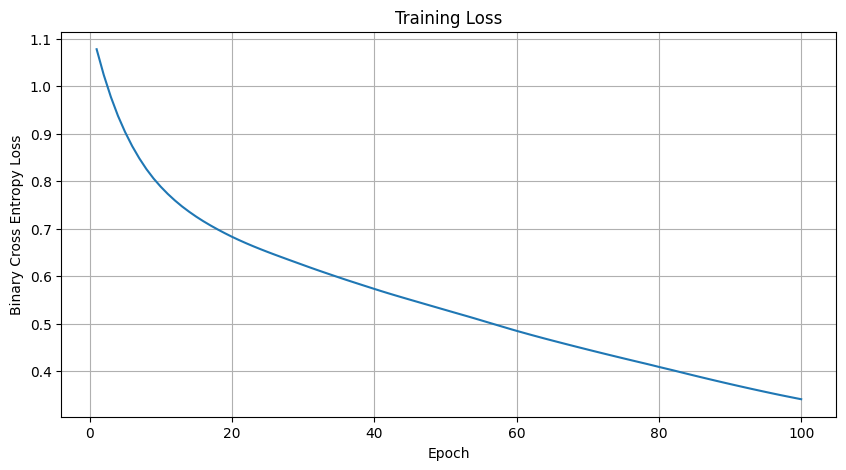

In [24]:
plt.figure(figsize=(10,5))
plt.plot(range(1, epochs+1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

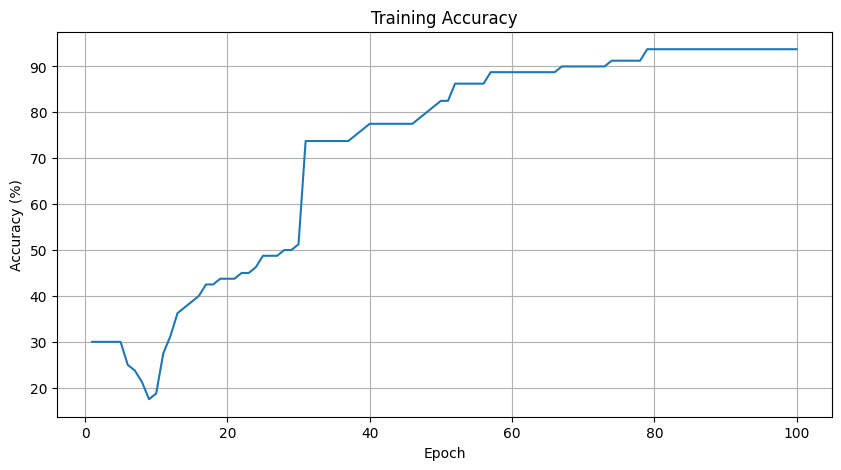

In [25]:
plt.figure(figsize=(10,5))
plt.plot(range(1, epochs+1), accuracy_history)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")
plt.grid(True)
plt.show()

In [26]:
def accuracy_mlp(W1, b1, W2, b2, test_x, test_labels):

    Z1 = np.dot(test_x, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    predictions = np.where(A2 >= 0.5, 1, -1)

    accuracy = np.mean(predictions.flatten() == test_labels)

    return accuracy

In [27]:
test_accuracy = accuracy_mlp(W1, b1, W2, b2, test_x, test_labels)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Accuracy: 100.00%


Earlier in this notebook, we trained a **Perceptron** on the XOR dataset. Despite training for many iterations, the best accuracy it could achieve was **75%**. This was not due to poor training or an incorrect implementation—it is a **fundamental limitation of the Perceptron itself**.

The Perceptron is a **linear classifier**, meaning it can only learn a **single linear decision boundary** (a straight line in two dimensions). This works well for **linearly separable datasets**, where one straight line can completely separate the positive and negative classes.

Unfortunately, the XOR dataset is **not linearly separable**. No matter where we place a single straight line, at least one of the four points will always be misclassified. As a result, the Perceptron can never perfectly solve the XOR problem.

This explains why our Perceptron reached approximately **75% accuracy**—it correctly classified three of the four XOR examples but always misclassified one point because no single linear boundary can separate all four samples simultaneously.

This limitation was one of the primary motivations behind the development of **Multi-Layer Perceptrons (MLPs)**.

Unlike a single-layer Perceptron, an MLP introduces one or more **hidden layers** together with **non-linear activation functions** such as ReLU, Sigmoid, or Tanh. These hidden layers enable the network to learn **non-linear decision boundaries**, allowing it to solve problems that are impossible for a single linear classifier.

In the following section, we will train our MLP on the exact same XOR dataset. This provides an excellent comparison because we already know the Perceptron's limitations. If our MLP is implemented correctly and trained using **forward propagation**, **Binary Cross-Entropy loss**, **backpropagation**, and **gradient descent**, it should successfully learn the XOR relationship and achieve perfect classification accuracy.

In [28]:
pos_examples_xor = np.array([ [1, 0], [0, 1]])
neg_examples_xor = np.array([[1, 1],[0, 0]])

# Complete dataset
xor_x = np.vstack((pos_examples_xor, neg_examples_xor))
xor_labels = np.array([1, 1, -1, -1])

In [30]:
def train_mlp_xor(positive_examples, negative_examples,  epochs=100, learning_rate=0.1):

    # Build dataset
    X = np.vstack((positive_examples, negative_examples))
    y = np.array([1]*len(positive_examples) +
                 [-1]*len(negative_examples))

    # Network architecture
    input_neurons = X.shape[1]
    hidden_neurons = 4
    output_neurons = 1

    # Initialize weights
    W1 = np.random.randn(input_neurons, hidden_neurons)
    b1 = np.zeros((1, hidden_neurons))

    W2 = np.random.randn(hidden_neurons, output_neurons)
    b2 = np.zeros((1, output_neurons))
    snapshots = []

    for epoch in range(epochs):

        Z1 = np.dot(X, W1) + b1
        A1 = relu(Z1)

        Z2 = np.dot(A1, W2) + b2
        A2 = sigmoid(Z2)
        print(A1.shape)
        print(A2.shape)

        loss = binary_cross_entropy(train_labels_bce, A2)
        m = X.shape[0]
        dZ2 = A2 - train_labels_bce

        dW2 = (1/m) * np.dot(A1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * relu_derivative(Z1)

        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
        W1 -= learning_rate*dW1
        b1 -= learning_rate*db1

        W2 -= learning_rate*dW2
        b2 -= learning_rate*db2
        predictions = np.where(A2 >= 0.5, 1, -1)
        accuracy = np.mean(predictions.flatten() == y)
        snapshots.append([epoch,loss,accuracy,W1.copy(), b1.copy(), W2.copy(), b2.copy()])
    return snapshots

In [33]:
snapshots = train_mlp_xor(pos_examples_xor, neg_examples_xor, epochs=10|0,  learning_rate=0.1)

(4, 4)
(4, 1)


ValueError: operands could not be broadcast together with shapes (80,1) (4,1) 

In [ ]:
losses = [s[1] for s in snapshots]
accuracies = [100*s[2] for s in snapshots]
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(losses)
plt.title("BCE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.show()

In [ ]:
W1 = snapshots[-1][3]
b1 = snapshots[-1][4]
W2 = snapshots[-1][5]
b2 = snapshots[-1][6]

Z1 = np.dot(xor_x, W1) + b1
A1 = relu(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)

predictions = np.where(A2 >= 0.5, 1, -1)
correct = 0

print("XOR Predictions\n")

for i in range(len(xor_x)):

    probability = A2[i,0]
    prediction = predictions[i,0]
    truth = xor_labels[i]

    status = "Correct" if prediction == truth else "Incorrect"

    if prediction == truth:
        correct += 1

    print(
        f"Input: {xor_x[i]} | "
        f"Probability: {probability:.4f} | "
        f"Predicted: {prediction:2d} | "
        f"True: {truth:2d} | "
        f"{status}"
    )

print("-"*70)
print(f"Accuracy: {100*correct/len(xor_labels):.2f}%")

## Deep Learning Frameworks

Throughout this chapter, we have built a Multi-Layer Perceptron (MLP) completely from scratch using **NumPy**. We manually implemented every stage of the learning process, including:

- Initializing weights and biases
- Forward propagation
- Activation functions
- Binary Cross-Entropy (BCE) loss
- Backpropagation
- Gradient descent
- Parameter updates
- Training over multiple epochs

Although implementing an MLP manually is an excellent way to understand the mathematics behind neural networks, this approach quickly becomes impractical as models become larger and more complex. Modern deep learning models may contain **millions or even billions of trainable parameters**, making manual implementations difficult to maintain, debug, and optimize.

To address this challenge, practitioners use **deep learning frameworks**, the most popular being **PyTorch** and **TensorFlow**. These frameworks provide highly optimized implementations of neural network components, allowing researchers and engineers to focus on designing models rather than implementing every mathematical operation from scratch.

### Why PyTorch?

PyTorch is an open-source deep learning framework developed by Meta AI and has become one of the most widely used libraries for deep learning research and production. It provides high-level modules for constructing and training neural networks while still allowing low-level control whenever needed.

With PyTorch, many of the components that we manually implemented are already available as built-in classes and functions. For example, PyTorch provides:

- Predefined neural network layers (Linear, Convolutional, Recurrent, Transformer, etc.)
- Activation functions (ReLU, Sigmoid, Tanh, Leaky ReLU, GELU, Softmax, and many others)
- Loss functions (Binary Cross-Entropy, Cross-Entropy, Mean Squared Error, etc.)
- Optimizers (SGD, Adam, RMSprop, AdamW, and others)
- Automatic differentiation using **Autograd**
- GPU acceleration with CUDA
- Dataset loading and preprocessing utilities

Instead of manually computing gradients and updating weights, PyTorch performs these operations automatically, significantly reducing both the amount of code and the likelihood of implementation errors.


### Tensors

At the heart of PyTorch is the **Tensor**.

A tensor is a multidimensional array that is conceptually similar to a NumPy array but provides several important advantages:

- Efficient CPU and GPU computation
- Automatic differentiation
- Seamless integration with neural network layers
- Efficient handling of large-scale data

If you are familiar with NumPy arrays, you can think of a PyTorch tensor as a more powerful version of a NumPy array that can also participate in gradient computation.

For example,

- A scalar is a 0-dimensional tensor.
- A vector is a 1-dimensional tensor.
- A matrix is a 2-dimensional tensor.
- Higher-dimensional arrays are simply higher-order tensors.

### Automatic Differentiation (Autograd)

One of PyTorch's most powerful features is **Automatic Differentiation**, commonly referred to as **Autograd**.

Recall that when implementing our MLP manually, we had to derive and code every gradient ourselves. We explicitly computed:

- The derivative of the Binary Cross-Entropy loss
- The derivative of the activation function
- The gradients of every weight matrix
- The gradients of every bias vector

This process becomes increasingly complicated as networks grow deeper.

PyTorch eliminates this burden by automatically constructing a **computational graph** during the forward pass. Once the loss has been computed, calling

```python
loss.backward()
```

automatically computes all required gradients using backpropagation.

Similarly, an optimizer such as Adam or SGD can update every trainable parameter with a single command:

```python
optimizer.step()
```

This automation allows developers to build sophisticated neural networks while relying on PyTorch to perform the underlying calculus correctly and efficiently.

### Rebuilding Our MLP in PyTorch

In the following sections, we will recreate the same Multi-Layer Perceptron that we previously implemented manually.

The overall architecture will remain identical:

- Input layer with two features
- One hidden layer containing four neurons
- ReLU activation
- One output neuron
- Sigmoid activation
- Binary Cross-Entropy loss
- Gradient-based optimization

The difference is that PyTorch will automatically manage the forward propagation, gradient computation, and parameter updates, allowing us to express the same model using only a few lines of code.

> **Further Reading:** PyTorch provides comprehensive documentation covering tensors, automatic differentiation, neural network modules, optimizers, datasets, and many advanced topics. Readers interested in learning more are encouraged to consult the official PyTorch documentation:
>
> https://pytorch.org/docs/stable/

In [ ]:
type(train_x)

In [ ]:
# Convert to tensors
train_x = torch.tensor(train_x, dtype=torch.float32)
train_y = torch.tensor(y_bce.reshape(-1,1), dtype=torch.float32)

test_x = torch.tensor(test_x, dtype=torch.float32)
test_y = torch.tensor(y_test_bce.reshape(-1,1), dtype=torch.float32)



In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2,4),
            nn.ReLU(),
            nn.Linear(4,1),
            nn.Sigmoid()
        )

    def forward(self, x):

        return self.network(x)

model = MLP()
print(model)

In [ ]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 100
loss_history = []
accuracy_history = []
for epoch in range(epochs):

    # Forward pass
    outputs = model(train_x)
    loss = criterion(outputs, train_y)
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Accuracy
    predictions = (outputs >= 0.5).float()
    accuracy = (predictions == train_y).float().mean()
    loss_history.append(loss.item())
    accuracy_history.append(accuracy.item())
    print(
        f"Epoch {epoch+1:3d}/{epochs} | "
        f"Loss: {loss.item():.4f} | "
        f"Accuracy: {accuracy.item()*100:.2f}%"
    )

In [ ]:
model.eval()
with torch.no_grad():
    outputs = model(test_x)
    predictions = (outputs >= 0.5).float()
    accuracy = (predictions == test_y).float().mean()
print(f"\nTest Accuracy: {accuracy.item()*100:.2f}%")